<a href="https://colab.research.google.com/github/jaysmerrill/Yaquina_Bay_Seiching/blob/main/seiche_prediction_rtdata_fullincorp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ UTC hygiene applied (tz-aware UTC throughout). No other edits required.
WL coverage: 2008-01-01 00:00:00+00:00 → 2025-12-31 20:00:00+00:00 (n=1,577,961)
NaNs before: 0, after fill(mode=none): 0
Upcrossings: n=380,933 | Waves (H): n=380,932
Finite fractions: bandpass=1.000, bp_for_xing=1.000
H_bin finite: 0.241 | Hrms finite: 1.000


✅ Forcings built: (1577961, 2) | X: (1577961, 1) | finite fraction: 1.0
   WL tide filter: Bessel SOS lowpass (order=4, Tc=1.00h)


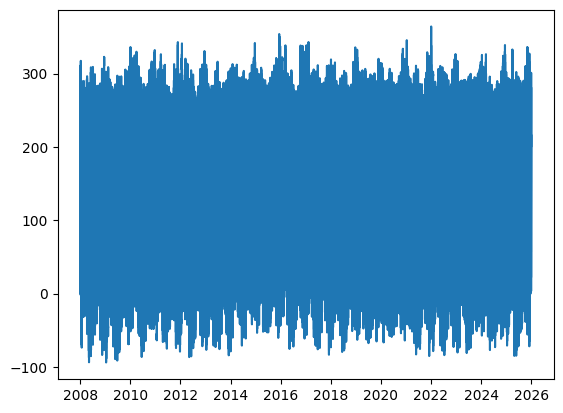

In [3]:
# ================================================
# Colab: Seiche forecast with PatchTST (XGB feature pick, forced baro_var4h)
# ================================================


# ============================================================
# Real-time forcings (no parquet) + var_wl (20–30 min bandpass → X-hour variance)
# Sources: NOAA CO-OPS 9435380 (WL, wind, air pressure), NDBC 46050 (stdmet, swden), HMSC (baro gap-fill)
# ============================================================

# -- If needed (Colab usually has torch already):
!pip -q install xgboost

import io, gzip, re, json, os, time, math, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
from contextlib import nullcontext
from sklearn.metrics import r2_score
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

from scipy import signal
!pip -q install plotly scipy
from scipy.signal import butter, filtfilt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "colab"   # critical in Colab

# =========================
# UTC HYGIENE — ONE DROP-IN
# Paste this block right after: from urllib3.util.retry import Retry
# No other edits needed in your code.
# =========================
import pandas as pd, numpy as np

# ---- helpers ----
def to_utc_ts(x) -> pd.Timestamp:
    if x is None: return pd.NaT
    t = pd.to_datetime(x, errors="coerce")
    if pd.isna(t): return pd.NaT
    if isinstance(t, pd.DatetimeIndex):
        t = t[0]
    if t.tz is None:
        return t.tz_localize("UTC")
    return t.tz_convert("UTC")

def to_utc_index(idx) -> pd.DatetimeIndex:
    if not isinstance(idx, pd.DatetimeIndex):
        idx = pd.to_datetime(idx, errors="coerce")
    if idx.tz is None:
        return idx.tz_localize("UTC")
    return idx.tz_convert("UTC")

def normalize_time_col(df: pd.DataFrame, col="time") -> pd.DataFrame:
    if df is None or not isinstance(df, pd.DataFrame) or len(df)==0 or col not in df.columns:
        return df
    out = df.copy()
    out[col] = pd.to_datetime(out[col], errors="coerce", utc=True)
    return (out.dropna(subset=[col]).sort_values(col).drop_duplicates(col).reset_index(drop=True))

# ---- wrap your parsers so they always emit UTC-aware 'time' ----
if "parse_stdmet_text" in globals():
    _old_parse_stdmet_text = parse_stdmet_text
    def parse_stdmet_text(txt: str) -> pd.DataFrame:
        df = _old_parse_stdmet_text(txt)
        return normalize_time_col(df, "time")
    globals()["parse_stdmet_text"] = parse_stdmet_text

if "parse_swden_year" in globals():
    _old_parse_swden_year = parse_swden_year
    def parse_swden_year(txt: str) -> pd.DataFrame:
        df = _old_parse_swden_year(txt)
        return normalize_time_col(df, "time")
    globals()["parse_swden_year"] = parse_swden_year

if "parse_noaa_wind_csv" in globals():
    _old_parse_noaa_wind_csv = parse_noaa_wind_csv
    def parse_noaa_wind_csv(txt: str) -> pd.DataFrame:
        df = _old_parse_noaa_wind_csv(txt)
        return normalize_time_col(df, "time")
    globals()["parse_noaa_wind_csv"] = parse_noaa_wind_csv

if "parse_noaa_wl_csv" in globals():
    _old_parse_noaa_wl_csv = parse_noaa_wl_csv
    def parse_noaa_wl_csv(txt: str) -> pd.DataFrame:
        df = _old_parse_noaa_wl_csv(txt)
        return normalize_time_col(df, "time")
    globals()["parse_noaa_wl_csv"] = parse_noaa_wl_csv

if "parse_hmsc_dat_avgbp_pa" in globals():
    _old_parse_hmsc_dat = parse_hmsc_dat_avgbp_pa
    def parse_hmsc_dat_avgbp_pa(txt: str) -> pd.DataFrame:
        df = _old_parse_hmsc_dat(txt)
        return normalize_time_col(df, "time")
    globals()["parse_hmsc_dat_avgbp_pa"] = parse_hmsc_dat_avgbp_pa

# ---- normalize any DataFrames already built ----
def _utcify_df(name):
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and len(globals()[name]):
        globals()[name] = normalize_time_col(globals()[name], "time")

for _nm in [
    "df_stdmet","df_swden","df_noaa_wind","df_wl6","df_varWL",
    "df_air","df_baro","df_baro_var","df_wind","df_46050","df_swd",
    "df_hmsc","df_hmsc_bp","df_all"
]:
    _utcify_df(_nm)

# ---- normalize common timestamps / ranges if they exist ----
for _tn in ["PRED_START","PRED_END","TRAIN_END","VAL_END","fill_start","fill_end","ap_start","ap_end"]:
    if _tn in globals():
        globals()[_tn] = to_utc_ts(globals()[_tn])

# Rebuild hourly_grid if fill_start/end exist
if "fill_start" in globals() and "fill_end" in globals() and pd.notna(globals()["fill_start"]) and pd.notna(globals()["fill_end"]):
    fs = to_utc_ts(globals()["fill_start"]); fe = to_utc_ts(globals()["fill_end"])
    globals()["hourly_grid"] = pd.date_range(fs.floor("H"), fe.ceil("H"), freq="H", tz="UTC")

# Rebuild baro hourly_grid if df_air exists
if "df_air" in globals() and isinstance(df_air, pd.DataFrame) and len(df_air):
    df_air = normalize_time_col(df_air, "time")
    ap_start = to_utc_ts(df_air["time"].min())
    ap_end   = to_utc_ts(df_air["time"].max())
    globals()["ap_start"] = ap_start; globals()["ap_end"] = ap_end
    globals()["hourly_grid"] = pd.date_range(ap_start.floor("H"), ap_end.ceil("H"), freq="H", tz="UTC")

# Rebuild modeling grid t_grid if inputs exist
def _maybe_tgrid():
    t0c=[]; t1c=[]
    for nm in ["df_varWL","df_swd","df_46050","df_wind","df_baro","df_baro_var"]:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame) and len(globals()[nm]):
            t0c.append(to_utc_ts(globals()[nm]["time"].min()))
            t1c.append(to_utc_ts(globals()[nm]["time"].max()))
    if t0c and t1c:
        t0 = max([t for t in t0c if pd.notna(t)])
        t1 = min([t for t in t1c if pd.notna(t)])
        if pd.notna(t0) and pd.notna(t1) and t1>t0:
            step = globals().get("DT_MINUTES", 6)
            return pd.date_range(t0, t1, freq=f"{step}min", tz="UTC")
    return None

tg = _maybe_tgrid()
if tg is not None:
    globals()["t_grid"] = tg

# Wrap interp helpers to enforce UTC indices
if "_interp_to_grid_series" in globals():
    _old_interp = _interp_to_grid_series
    def _interp_to_grid_series(times, values, grid):
        times = to_utc_index(times); grid = to_utc_index(grid)
        s = pd.Series(values, index=times)
        u = s.reindex(pd.to_datetime(sorted(set(s.index).union(set(grid)))))
        u = u.interpolate(method="time", limit_area="inside")
        return u.reindex(grid).to_numpy()
    globals()["_interp_to_grid_series"] = _interp_to_grid_series

if "interp_timegrid" in globals():
    _old_interp2 = interp_timegrid
    def interp_timegrid(t_src: pd.Series, x_src: np.ndarray, t_grid: pd.DatetimeIndex) -> np.ndarray:
        t_src = to_utc_index(t_src); t_grid = to_utc_index(t_grid)
        s = pd.Series(x_src, index=t_src)
        u = s.reindex(pd.to_datetime(sorted(set(s.index).union(set(t_grid)))))
        u = u.interpolate(method="time", limit_area="inside")
        return u.reindex(t_grid).to_numpy()
    globals()["interp_timegrid"] = interp_timegrid

# Gap utilities and EQ decay: enforce UTC
if "gap_intervals" in globals():
    _old_gap = gap_intervals
    def gap_intervals(t: pd.Series, x: np.ndarray, min_gap_hours: float):
        t = to_utc_index(t)
        return _old_gap(t, x, min_gap_hours)
    globals()["gap_intervals"] = gap_intervals

if "merge_intervals" in globals():
    _old_merge = merge_intervals
    def merge_intervals(intervals):
        out = _old_merge(intervals)
        return [(to_utc_ts(a), to_utc_ts(b)) for a,b in out]
    globals()["merge_intervals"] = merge_intervals

if "build_eq_decay_series" in globals():
    _old_eq = build_eq_decay_series
    def build_eq_decay_series(t_grid: pd.DatetimeIndex, eq_events):
        t_grid = to_utc_index(t_grid)
        eq_fixed = []
        for t0_evt, M in (eq_events or []):
            eq_fixed.append((to_utc_ts(t0_evt), M))
        return _old_eq(t_grid, eq_fixed)
    globals()["build_eq_decay_series"] = build_eq_decay_series

print("✅ UTC hygiene applied (tz-aware UTC throughout). No other edits required.")



# -------------------
# USER KNOBS
# -------------------
YEARS                = list(range(2008, pd.Timestamp.utcnow().year + 1))
DT_MINUTES           = 6  # common model grid
WL_BAND_MIN_MIN      = 20.0
WL_BAND_MAX_MIN      = 30.0
VAR_WIN_HOURS        = 2.0     # <-- default window for variance of band-passed WL (tweakable)
NOAA_STATION         = "9435380"  # Newport / South Beach
NOAA_BEGIN_DATE      = "20080101"
NOAA_END_DATE        = pd.Timestamp.utcnow().strftime("%Y%m%d")
NOAA_CHUNK_DAYS      = 365

# HMSC monthly archive (baro gap fill for NOAA air_pressure ≥3h gaps; <3h: spline)
HMSC_UTC_OFFSET_H    = +8
INHG_TO_PA           = 3386.389

# NDBC buoy 46050
BUOY                 = "46050"

# Optional preview window for plots
PRED_START           = None  # e.g., pd.Timestamp("2022-11-01")
PRED_END             = None  # e.g., pd.Timestamp("2022-12-15")


def _make_session():
    s = requests.Session()
    retry = Retry(total=4, backoff_factor=0.6, status_forcelist=(429,500,502,503,504),
                  allowed_methods=["HEAD","GET","OPTIONS"], raise_on_status=False)
    s.headers.update({"User-Agent":"Mozilla/5.0 (X11; Linux x86_64) RealtimeForcings/1.0", "Accept":"*/*"})
    s.mount("https://", HTTPAdapter(max_retries=retry))
    s.mount("http://", HTTPAdapter(max_retries=retry))
    return s
session = _make_session()

def _datestr(dt) -> str:
    return pd.Timestamp(dt).strftime("%Y%m%d")

# -------------------
# NOAA CO-OPS: Water Level (6-min) + bandpass(20–30min) + centered rolling variance -> var_wl
# -------------------
def parse_noaa_wl_csv(txt:str)->pd.DataFrame:
    if txt.strip().lower().startswith("error"):
        return pd.DataFrame(columns=["time","wl"])
    df = pd.read_csv(io.StringIO(txt))
    if df.shape[1] < 2: return pd.DataFrame(columns=["time","wl"])
    df.columns = [str(c).strip().lower().replace("  "," ") for c in df.columns]
    tcol=None
    for k in ("date time","date_time","time","t","date"):
        if k in df.columns: tcol=k; break
    if tcol is None: return pd.DataFrame(columns=["time","wl"])
    df["time"] = pd.to_datetime(df[tcol], errors="coerce", utc=True).dt.tz_localize(None)
    vcol=None
    for k in ("water level","water_level","wl","v"):
        if k in df.columns: vcol=k; break
    if vcol is None: vcol = df.columns[1]
    df["wl"] = pd.to_numeric(df[vcol], errors="coerce")
    out = df[["time","wl"]].dropna(subset=["time"]).sort_values("time").drop_duplicates("time")
    out.loc[(out["wl"]<-50)|(out["wl"]>50),"wl"]=np.nan
    return out.reset_index(drop=True)

def fetch_noaa_wl(begin_date:str, end_date:str, station:str, days_per_chunk:int=31)->pd.DataFrame:
    start = pd.to_datetime(begin_date, format="%Y%m%d"); end = pd.to_datetime(end_date, format="%Y%m%d")
    frames=[]
    cur=start
    while cur <= end:
        chunk_end = min(end, cur + pd.Timedelta(days=days_per_chunk-1))
        url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
               f"?begin_date={_datestr(cur)}&end_date={_datestr(chunk_end)}"
               f"&station={station}&product=water_level&datum=MLLW&time_zone=gmt&units=metric"
               f"&interval=6&application=RealtimeForcings&format=csv")
        try:
            r = session.get(url, timeout=90)
            if r.status_code==200 and r.content:
                dfc = parse_noaa_wl_csv(r.content.decode("utf-8","ignore"))
                if not dfc.empty: frames.append(dfc)
        except: pass
        cur = chunk_end + pd.Timedelta(days=1)
    if not frames: return pd.DataFrame(columns=["time","wl"])
    return pd.concat(frames, ignore_index=True).sort_values("time").drop_duplicates("time").reset_index(drop=True)

# ============================================================
# NOAA WL (6-min) → 20–30 min bandpass → zero-upcross HF wave heights → trailing smoothing
# (No centering on timestep: no center=True rolling; default causal filter)
# ============================================================
from scipy import signal
# -------------------
# USER KNOBS (HF heights)
# -------------------
HF_SMOOTH_HOURS       = VAR_WIN_HOURS  # trailing smoothing window for H (hours)
MAX_GAP_FILL_HOURS    = 3.0            # only relevant if GAP_FILL_MODE != "none"
GAP_FILL_MODE         = "none"         # "none" (recommended for strict real-time) OR "ffill" (causal fill)
BASELINE_REMOVAL_H    = 2.0            # trailing baseline removal window (hours) for robust zero-crossing
FILTER_ORDER          = 4              # keep modest (4–6). Higher => more ringing / more delay risk
PLOT_DAYS             = 30             # render last N days for interactivity
PLOT_MAX_UPCROSS_MARKERS = 8000        # cap markers so Plotly doesn't choke

# -------------------
# Fetch WL + convert to cm
# -------------------
df_wl6  = fetch_noaa_wl(NOAA_BEGIN_DATE, NOAA_END_DATE, NOAA_STATION, days_per_chunk=31).copy()
df_wl6  = normalize_time_col(df_wl6, "time")  # enforce UTC-aware time
df_wl6["wl_cm"] = df_wl6["wl"].astype(float) * 100.0

print("WL coverage:",
      (df_wl6["time"].min() if len(df_wl6) else None), "→",
      (df_wl6["time"].max() if len(df_wl6) else None), f"(n={len(df_wl6):,})")

# -------------------
# Regular 6-min grid (UTC) + OPTIONAL causal gap fill
# -------------------
dt_minutes = DT_MINUTES
t0 = df_wl6["time"].min()
t1 = df_wl6["time"].max()

grid = pd.date_range(
    pd.Timestamp(t0).floor(f"{dt_minutes}min"),
    pd.Timestamp(t1).ceil(f"{dt_minutes}min"),
    freq=f"{dt_minutes}min",
    tz="UTC"
)

s_cm = df_wl6.set_index("time")["wl_cm"].reindex(grid)

limit_samples = int(round((MAX_GAP_FILL_HOURS * 60.0) / dt_minutes))  # e.g., 3h at 6-min => 30 samples
nan_before = int(s_cm.isna().sum())

if GAP_FILL_MODE == "ffill":
    # CAUSAL fill only (uses past only). Good for operational continuity, but can introduce steps.
    s_cm_filled = s_cm.ffill(limit=limit_samples)
else:
    # Strict real-time: no future-peeking fills; let gaps break the record.
    s_cm_filled = s_cm.copy()

nan_after = int(s_cm_filled.isna().sum())
print(f"NaNs before: {nan_before}, after fill(mode={GAP_FILL_MODE}): {nan_after}")

df_wl6_cm_clean = pd.DataFrame({"time": grid, "wl_cm": s_cm_filled.values})

# -------------------
# CAUSAL 20–30 min bandpass (SOS)
# -------------------
dt_sec = dt_minutes * 60.0
fs     = 1.0 / dt_sec
f_lo   = 1.0 / (WL_BAND_MAX_MIN * 60.0)   # longer-period edge (30 min)
f_hi   = 1.0 / (WL_BAND_MIN_MIN * 60.0)   # shorter-period edge (20 min)
wn     = [max(1e-6, f_lo/(fs/2.0)), min(0.999, f_hi/(fs/2.0))]

# Prefer Bessel for flatter group delay (less waveform distortion), but fallback safely.
try:
    sos = signal.bessel(FILTER_ORDER, wn, btype="bandpass", output="sos", norm="phase")
    filter_name = f"Bessel SOS (order={FILTER_ORDER})"
except Exception:
    sos = signal.butter(FILTER_ORDER, wn, btype="bandpass", output="sos")
    filter_name = f"Butterworth SOS (order={FILTER_ORDER})"

def _filter_chunks_sos_causal(x: np.ndarray, sos, min_len: int = 60) -> np.ndarray:
    """
    Causal SOS filtering only on contiguous finite segments.
    - keeps NaNs as NaNs
    - does NOT use future samples
    """
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    good = np.isfinite(x)
    if not good.any():
        return y

    idx = np.arange(len(x))
    splits = np.where(np.diff(good.astype(int)) != 0)[0] + 1
    runs = np.split(idx, splits)

    for r in runs:
        if not good[r].all():
            continue
        if len(r) < min_len:
            continue

        seg = x[r]

        # Causal initialization: steady-state zi scaled by first sample
        zi = signal.sosfilt_zi(sos) * seg[0]
        y[r], _ = signal.sosfilt(sos, seg, zi=zi)

    return y

x_cm = s_cm_filled.to_numpy(dtype=float)

# Require at least ~2 hours of data per segment to get stable bandpass for crossings
min_len = max(60, int(round((120.0) / dt_minutes)))  # 120 minutes worth of samples
x_bp_cm = _filter_chunks_sos_causal(x_cm, sos, min_len=min_len)

# -------------------
# Trailing baseline removal (causal) to stabilize 0-crossing reference
# (prevents “offset” issues without using future data)
# -------------------
baseline_win = max(3, int(round((BASELINE_REMOVAL_H * 60.0) / dt_minutes)))
bp_series = pd.Series(x_bp_cm, index=grid)
bp_base   = bp_series.rolling(window=baseline_win, center=False, min_periods=baseline_win).mean()
bp_for_xing = (bp_series - bp_base).to_numpy(dtype=float)  # still NaNs where baseline undefined

# -------------------
# Streaming-style zero-upcrossings + wave heights (causal)
# Wave height between successive upcrossings, assigned at time of 2nd upcross.
# -------------------
def zero_upcross_streaming(time_index: pd.DatetimeIndex, eta: np.ndarray):
    """
    Causal zero-upcross processing.
    Returns:
      df_uc: upcross times (interpolated within sample), per-segment
      df_w : wave heights (crest-trough) between successive upcrossings, timestamped at 2nd upcross
    """
    t = pd.to_datetime(time_index)
    x = np.asarray(eta, dtype=float)

    out_uc_t = []
    out_w_t  = []
    out_w_H  = []

    good = np.isfinite(x)
    if not good.any():
        return (pd.DataFrame(columns=["time"]), pd.DataFrame(columns=["time","H_cm"]))

    idx = np.arange(len(x))
    splits = np.where(np.diff(good.astype(int)) != 0)[0] + 1
    runs = np.split(idx, splits)

    for r in runs:
        if len(r) < 3 or not good[r].all():
            continue

        # State for current wave
        have_prev = False
        prev_val  = np.nan
        prev_t    = None

        in_wave = False
        w_min = np.inf
        w_max = -np.inf
        last_uc_time = None

        for ii in r:
            xi = x[ii]
            ti = t[ii]

            if not have_prev:
                have_prev = True
                prev_val = xi
                prev_t = ti
                continue

            # Update extrema for current wave (only after we've entered a wave)
            if in_wave:
                if xi < w_min: w_min = xi
                if xi > w_max: w_max = xi

            # Detect upcross: prev <= 0 and curr > 0
            if (prev_val <= 0.0) and (xi > 0.0):
                # Interpolate crossing time (linear)
                y0, y1 = prev_val, xi
                frac = 0.0 if (y1 == y0) else (-y0) / (y1 - y0)
                tc = prev_t + (ti - prev_t) * frac

                out_uc_t.append(tc)

                if last_uc_time is None:
                    # first upcross: start new wave immediately after crossing
                    last_uc_time = tc
                    in_wave = True
                    w_min = min(prev_val, xi)
                    w_max = max(prev_val, xi)
                else:
                    # finalize previous wave (between last_uc_time and this tc)
                    H = float(w_max - w_min) if np.isfinite(w_max) and np.isfinite(w_min) else np.nan
                    out_w_t.append(tc)   # assign at second upcross (causal)
                    out_w_H.append(H)

                    # start next wave
                    last_uc_time = tc
                    in_wave = True
                    w_min = min(prev_val, xi)
                    w_max = max(prev_val, xi)

            prev_val = xi
            prev_t = ti

    df_uc = pd.DataFrame({"time": out_uc_t}).sort_values("time").reset_index(drop=True)
    df_w  = pd.DataFrame({"time": out_w_t, "H_cm": out_w_H}).sort_values("time").reset_index(drop=True)
    return df_uc, df_w

df_upcross, df_waves = zero_upcross_streaming(grid, bp_for_xing)
print(f"Upcrossings: n={len(df_upcross):,} | Waves (H): n={len(df_waves):,}")

# -------------------
# Bin wave heights to the 6-min grid (label on RIGHT edge; still causal)
# -------------------
if len(df_waves):
    H_series = pd.Series(df_waves["H_cm"].to_numpy(dtype=float), index=pd.to_datetime(df_waves["time"]))
    H_bin = (
        H_series
        .resample(f"{dt_minutes}min", label="right", closed="right")
        .mean()
        .reindex(grid)
    )
else:
    H_bin = pd.Series(index=grid, data=np.nan)

# Trailing smoothing (causal)
win  = max(3, int(round((HF_SMOOTH_HOURS * 60.0) / dt_minutes)))
minp = max(2, int(0.8 * win))
H_smooth = H_bin.rolling(window=win, center=False, min_periods=minp).mean()

df_hfH_cm = pd.DataFrame({
    "time": grid,
    "hfH_cm": H_bin.astype("float32").values,
    "hfH_cm_smooth": H_smooth.astype("float32").values
})

# =========================
# (A) HRMS(t): causal amplitude proxy for the 20–30 min bandpassed signal
#     Hrms(t) ≈ 2*sqrt(2)*RMS( bandpass_detrended ) over a trailing window
# =========================

# Detrend for amplitude/energy (causal trailing mean; min_periods=1 keeps it defined)
bp_detr = bp_series - bp_series.rolling(window=baseline_win, center=False, min_periods=1).mean()

# Trailing RMS window (you can set HRMS_WIN_HOURS separately if you want)
hrms_win = max(3, int(round((HF_SMOOTH_HOURS * 60.0) / dt_minutes)))
hrms_minp = max(2, int(0.8 * hrms_win))

bp_rms = np.sqrt((bp_detr**2).rolling(window=hrms_win, center=False, min_periods=hrms_minp).mean())
Hrms_cm = 2.0 * np.sqrt(2.0) * bp_rms  # peak-to-trough equivalent for sinusoid-ish signals

# Optional: extra trailing smoothing on Hrms itself (keeps response very stable)
Hrms_cm_smooth = Hrms_cm.rolling(window=hrms_win, center=False, min_periods=hrms_minp).mean()

df_hrms = pd.DataFrame({
    "time": grid,
    "Hrms_cm": Hrms_cm.astype("float32").to_numpy(),
    "Hrms_cm_smooth": Hrms_cm_smooth.astype("float32").to_numpy()
})

# Quick sanity (helps debug "blank plots")
finite_bp = float(np.isfinite(x_bp_cm).mean()) if len(x_bp_cm) else 0.0
finite_bp0 = float(np.isfinite(bp_for_xing).mean()) if len(bp_for_xing) else 0.0
print(f"Finite fractions: bandpass={finite_bp:.3f}, bp_for_xing={finite_bp0:.3f}")
print(f"H_bin finite: {float(np.isfinite(df_hfH_cm['hfH_cm'].to_numpy()).mean()):.3f} | "
      f"Hrms finite: {float(np.isfinite(df_hrms['Hrms_cm'].to_numpy()).mean()):.3f}")


# =========================
# (B) Plot window (last PLOT_DAYS) — use direct boolean indexing (no pandas .loc surprises)
# =========================
t_end = pd.to_datetime(grid.max(), utc=True) if len(grid) else None
t_start = (t_end - pd.Timedelta(days=PLOT_DAYS)) if t_end is not None else None

mask = np.ones(len(grid), dtype=bool)
if t_start is not None and t_end is not None:
    tg = pd.to_datetime(grid, utc=True)
    mask = (tg >= t_start) & (tg <= t_end)

grid_p   = pd.to_datetime(grid[mask], utc=True)
wl_p     = df_wl6_cm_clean["wl_cm"].to_numpy(dtype=float)[mask]
bp_p     = x_bp_cm[mask]
bp0_p    = bp_for_xing[mask]

hfH_p    = df_hfH_cm["hfH_cm"].to_numpy(dtype=float)[mask]
hfHsm_p  = df_hfH_cm["hfH_cm_smooth"].to_numpy(dtype=float)[mask]

hrms_p   = df_hrms["Hrms_cm"].to_numpy(dtype=float)[mask]
hrmss_p  = df_hrms["Hrms_cm_smooth"].to_numpy(dtype=float)[mask]


# Upcross markers in plot window (cap for Plotly)
if len(df_upcross) and (t_start is not None) and (t_end is not None):
    uc_in = df_upcross[
        (pd.to_datetime(df_upcross["time"], utc=True) >= t_start) &
        (pd.to_datetime(df_upcross["time"], utc=True) <= t_end)
    ]
    if len(uc_in) > PLOT_MAX_UPCROSS_MARKERS:
        step = max(2, len(uc_in)//PLOT_MAX_UPCROSS_MARKERS)
        uc_in = uc_in.iloc[::step]
    uc_t = pd.to_datetime(uc_in["time"], utc=True)
else:
    uc_t = pd.to_datetime([], utc=True)

# Raw wave heights (QA markers) in plot window (cap for Plotly)
if len(df_waves) and (t_start is not None) and (t_end is not None):
    w_in = df_waves[
        (pd.to_datetime(df_waves["time"], utc=True) >= t_start) &
        (pd.to_datetime(df_waves["time"], utc=True) <= t_end)
    ]
    if len(w_in) > PLOT_MAX_UPCROSS_MARKERS:
        step = max(2, len(w_in)//PLOT_MAX_UPCROSS_MARKERS)
        w_in = w_in.iloc[::step]
    w_t = pd.to_datetime(w_in["time"], utc=True)
    w_H = w_in["H_cm"].to_numpy(dtype=float)
else:
    w_t = pd.to_datetime([], utc=True)
    w_H = np.array([], dtype=float)


# =========================
# (C) INTERACTIVE PLOTLY FIGURE (4 rows): WL, bandpass+upcross, zero-upcross H, Hrms
# =========================
fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.035,
    row_heights=[0.34, 0.26, 0.20, 0.20],
    subplot_titles=(
        "Water level (cm)",
        f"20–30 min causal bandpass (cm) [{filter_name}] + zero upcrossings",
        f"Zero-upcross wave heights H (cm): raw markers + binned + trailing mean ({HF_SMOOTH_HOURS:.1f} h)",
        f"Hrms(t) (cm): causal amplitude proxy + trailing mean ({HF_SMOOTH_HOURS:.1f} h)"
    )
)

# Row 1: WL
fig.add_trace(go.Scattergl(x=grid_p, y=wl_p, mode="lines", name="WL (cm)"),
              row=1, col=1)

# Row 2: bandpass raw + baseline-removed (for crossing reference)
fig.add_trace(go.Scattergl(x=grid_p, y=bp_p, mode="lines", name="Bandpass (raw)", opacity=0.60),
              row=2, col=1)
fig.add_trace(go.Scattergl(x=grid_p, y=bp0_p, mode="lines",
                           name="Bandpass (baseline-removed for crossings)", opacity=0.85),
              row=2, col=1)

# Upcross markers at y=0
if len(uc_t):
    fig.add_trace(go.Scattergl(x=uc_t, y=np.zeros(len(uc_t)),
                               mode="markers", name="Zero upcrossings", marker=dict(size=5)),
                  row=2, col=1)

# Row 3: zero-upcross wave heights — raw markers (QA) + binned line + smooth line
if len(w_t):
    fig.add_trace(go.Scattergl(x=w_t, y=w_H, mode="markers",
                               name="H raw (per wave)", marker=dict(size=5), opacity=0.55),
                  row=3, col=1)

fig.add_trace(go.Scattergl(x=grid_p, y=hfH_p, mode="lines",
                           name="H binned (6-min)", opacity=0.55),
              row=3, col=1)
fig.add_trace(go.Scattergl(x=grid_p, y=hfHsm_p, mode="lines",
                           name="H trailing mean"),
              row=3, col=1)

# Row 4: Hrms(t)
fig.add_trace(go.Scattergl(x=grid_p, y=hrms_p, mode="lines",
                           name="Hrms (2√2·RMS)", opacity=0.60),
              row=4, col=1)
fig.add_trace(go.Scattergl(x=grid_p, y=hrmss_p, mode="lines",
                           name="Hrms trailing mean"),
              row=4, col=1)

fig.update_yaxes(title_text="cm", row=1, col=1)
fig.update_yaxes(title_text="cm", row=2, col=1, zeroline=True, zerolinewidth=1)
fig.update_yaxes(title_text="cm", row=3, col=1)
fig.update_yaxes(title_text="cm", row=4, col=1)

fig.update_xaxes(title_text="Time (UTC)", row=4, col=1, rangeslider_visible=True)

fig.update_layout(
    height=980,
    title=(f"NOAA {NOAA_STATION}: WL → causal bandpass → (QA) zero-upcross H and (target) Hrms(t) | "
           f"plot last {PLOT_DAYS} days | gap_fill={GAP_FILL_MODE}"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1.0)
)

fig.show(config={"scrollZoom": True, "displaylogo": False})


# ---- sanity: requires your existing common grid + WL-on-grid ----
assert "grid" in globals(), "Expected 'grid' (UTC DateTimeIndex) to exist."
assert "df_wl6_cm_clean" in globals(), "Expected 'df_wl6_cm_clean' to exist."

# WL on the common grid (cm); keep NaNs where WL is missing / baseline undefined
wl_cm = pd.Series(df_wl6_cm_clean["wl_cm"].to_numpy(dtype=float), index=pd.to_datetime(grid, utc=True))

# ---- causal SOS filtering on contiguous finite segments (no future leakage) ----
def _filter_chunks_sos_causal(x: np.ndarray, sos, min_len: int = 20) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)

    good = np.isfinite(x)
    if not good.any():
        return y

    idx = np.arange(len(x))
    splits = np.where(np.diff(good.astype(int)) != 0)[0] + 1
    runs = np.split(idx, splits)

    for r in runs:
        if not good[r].all():
            continue
        if len(r) < min_len:
            continue

        seg = x[r]

        # Causal initialization: steady-state zi scaled by first sample
        zi = signal.sosfilt_zi(sos) * seg[0]
        y[r], _ = signal.sosfilt(sos, seg, zi=zi)

    return y

# ---- 1-hour lowpass cutoff (keeps tide/subtidal; removes <1h variability) ----
TIDE_LP_CUTOFF_HOURS = 1.0
TIDE_FILTER_ORDER   = 4

dt_minutes = DT_MINUTES
dt_sec     = dt_minutes * 60.0
fs         = 1.0 / dt_sec                 # Hz
fc         = 1.0 / (TIDE_LP_CUTOFF_HOURS * 3600.0)  # Hz (period = 1 hour)
wn_lp      = min(0.999, max(1e-6, fc / (fs / 2.0)))

try:
    sos_lp = signal.bessel(TIDE_FILTER_ORDER, wn_lp, btype="lowpass",
                           output="sos", norm="phase")
    _lp_name = f"Bessel SOS lowpass (order={TIDE_FILTER_ORDER}, Tc={TIDE_LP_CUTOFF_HOURS:.2f}h)"
except Exception:
    sos_lp = signal.butter(TIDE_FILTER_ORDER, wn_lp, btype="lowpass", output="sos")
    _lp_name = f"Butter SOS lowpass (order={TIDE_FILTER_ORDER}, Tc={TIDE_LP_CUTOFF_HOURS:.2f}h)"

wl_tide_cm = _filter_chunks_sos_causal(wl_cm.to_numpy(dtype=float), sos_lp, min_len=max(20, int(round(3*60/dt_minutes))))
wl_tide_cm = wl_tide_cm.astype("float32")

# ---- forcings structure (add more columns later) ----
df_forcings = pd.DataFrame({
    "time": pd.to_datetime(grid, utc=True),
    "wl_tide_cm": wl_tide_cm,     # tidal/subtidal WL forcing (cm)
})

forcing_names = ["wl_tide_cm"]
X_forcings = df_forcings[forcing_names].to_numpy(dtype=np.float32)  # (T, n_forcings)

FORCINGS = {
    "time": df_forcings["time"].to_numpy(),
    "names": forcing_names,
    "X": X_forcings,
    "df": df_forcings,
    "meta": {"wl_tide_filter": _lp_name, "dt_minutes": dt_minutes},
}

print("✅ Forcings built:", df_forcings.shape, "| X:", X_forcings.shape, "| finite fraction:",
      float(np.isfinite(X_forcings).mean()))
print("   WL tide filter:", _lp_name)

plt.plot(pd.to_datetime(grid, utc=True),wl_tide_cm)


NOAA coverage: 2008-01-01 00:00:00 → 2025-12-15 23:00:00 (n=147,266)
HMSC hourly coverage: 2010-10-23 16:00:00 → 2025-11-30 23:00:00 (n=132,416)
Merged (NOAA + HMSC≥3h gaps) coverage: 2008-01-01 00:00:00 → 2025-12-15 23:00:00 (n=157,416)


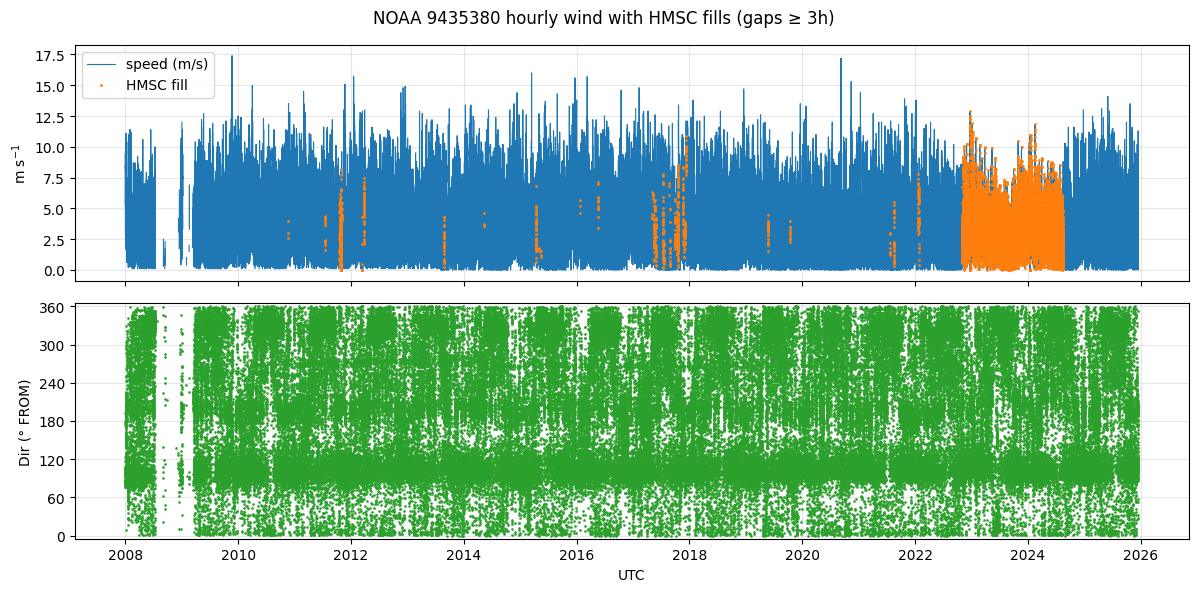

In [ ]:
session = requests.Session()

# --- Config (edit as needed) ---
NOAA_BEGIN_DATE = "20080101"
NOAA_END_DATE   = "20251215"
NOAA_STATION    = "9435380"
NOAA_CHUNK_DAYS = 365

session = requests.Session()

def _datestr(dt) -> str:
    return pd.Timestamp(dt).strftime("%Y%m%d")

# ======================
# NOAA (hourly, metric)
# ======================
def parse_noaa_wind_csv(txt: str) -> pd.DataFrame:
    df = pd.read_csv(io.StringIO(txt))
    # Normalize headers
    df.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df.columns]

    # Time col: prefer "Date Time", else anything containing time/date
    lc = [c.lower() for c in df.columns]
    try:
        tcol = df.columns[lc.index("date time")]
    except ValueError:
        tcol = next((c for c in df.columns if any(k in c.lower() for k in ("date time","date_time","time","date","t"))),
                    df.columns[0])
    out = pd.DataFrame()
    out["time"] = pd.to_datetime(df[tcol], errors="coerce", utc=True).dt.tz_localize(None)

    # Select best numeric speed & direction columns
    def best_numeric(cands):
        best, nbest = None, -1
        for c in cands:
            vals = pd.to_numeric(df[c], errors="coerce")
            cnt  = np.isfinite(vals).sum()
            if cnt > nbest: best, nbest = c, cnt
        return best

    speed_cands = [c for c in df.columns if ("speed" in c.lower()) or (c.lower() == "s")]
    dir_cands   = [c for c in df.columns if ("direction" in c.lower()) or (c.lower() in ("dir","d"))]

    sp_col  = best_numeric(speed_cands) if speed_cands else None
    dir_col = best_numeric(dir_cands)   if dir_cands   else None

    out["speed"] = pd.to_numeric(df[sp_col], errors="coerce") if sp_col else np.nan
    out["dir"]   = pd.to_numeric(df[dir_col], errors="coerce") if dir_col else np.nan

    # QC
    out.loc[(out["speed"] < 0) | (out["speed"] > 100), "speed"] = np.nan
    out.loc[(out["dir"]   < 0) | (out["dir"]   > 360), "dir"]   = np.nan

    out = (out.dropna(subset=["time"])
              .sort_values("time")
              .drop_duplicates("time")
              .reset_index(drop=True))
    return out

def fetch_noaa_wind_dataframe(begin_date: str, end_date: str, station: str,
                              days_per_chunk: int = 365) -> pd.DataFrame:
    start = pd.to_datetime(begin_date, format="%Y%m%d")
    end   = pd.to_datetime(end_date,   format="%Y%m%d")
    frames, cur = [], start
    while cur <= end:
        chunk_end = min(end, cur + pd.Timedelta(days=days_per_chunk-1))
        url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
               f"?begin_date={_datestr(cur)}&end_date={_datestr(chunk_end)}"
               f"&station={station}&product=wind&time_zone=gmt&interval=h&units=metric"
               "&application=DataAPI_Sample&format=csv")
        try:
            r = session.get(url, timeout=90)
            if r.ok and r.content:
                dfc = parse_noaa_wind_csv(r.content.decode("utf-8", "ignore"))
                if not dfc.empty: frames.append(dfc)
        except Exception:
            pass
        cur = chunk_end + pd.Timedelta(days=1)

    if not frames:
        return pd.DataFrame(columns=["time","speed","dir"])

    df = (pd.concat(frames, ignore_index=True)
            .sort_values("time")
            .drop_duplicates("time")
            .reset_index(drop=True))
    return df

# ======================
# HMSC (5-min .dat)
# ======================
HMSC_BASE = "http://weather.hmsc.oregonstate.edu/weather/weatherproject/archive/{year}/HMSC_{year}{mm:02d}.dat"

def parse_hmsc_month(txt: str, year: int, month: int) -> pd.DataFrame:
    rows = []
    for ln in txt.splitlines():
        s = ln.strip()
        # Skip header/meta lines (quoted headers or empty)
        if not s or s.startswith('"TOA5"') or s.startswith('"TIMESTAMP"') or s.startswith('"TS"') or s.startswith('"",'):
            continue
        parts = [p.strip().strip('"') for p in s.split(",")]
        if len(parts) < 4:
            continue
        ts      = parts[0]          # "YYYY-MM-DD HH:MM:SS"
        aws_mph = parts[2]          # AWS (mph)
        awd_deg = parts[3]          # AWD (deg FROM north)

        # Time: local Pacific → UTC (naive)
        try:
            t_local = pd.to_datetime(ts, errors="coerce")
            if pd.isna(t_local):
                continue
            t_local = t_local.tz_localize("America/Los_Angeles", nonexistent="NaT", ambiguous="NaT")
            t_utc   = t_local.tz_convert("UTC").tz_localize(None)
        except Exception:
            continue

        try: spd = float(aws_mph)
        except: spd = np.nan
        try: dr  = float(awd_deg)
        except: dr  = np.nan

        if not (0 <= spd <= 200): spd = np.nan
        if not (0 <= dr  <= 360): dr  = np.nan

        rows.append((t_utc, spd, dr))

    if not rows:
        return pd.DataFrame(columns=["time","spd_mps","dir_deg"])

    df = pd.DataFrame(rows, columns=["time","aws_mph","awd_deg"])
    df["spd_mps"] = df["aws_mph"] * 0.44704              # mph → m/s
    df["dir_deg"] = df["awd_deg"]
    df = (df.drop(columns=["aws_mph","awd_deg"])
            .dropna(subset=["time"])
            .sort_values("time")
            .drop_duplicates("time")
            .reset_index(drop=True))
    # Keep only that month (safety)
    return df[(df["time"].dt.year == year) & (df["time"].dt.month == month)]

def fetch_hmsc_wind(begin_date: str, end_date: str) -> pd.DataFrame:
    start = pd.to_datetime(begin_date, format="%Y%m%d")
    end   = pd.to_datetime(end_date,   format="%Y%m%d")
    frames=[]
    for year in range(start.year, end.year+1):
        m0 = 1 if year > start.year else start.month
        m1 = 12 if year < end.year   else end.month
        for mm in range(m0, m1+1):
            url = HMSC_BASE.format(year=year, mm=mm)
            try:
                r = session.get(url, timeout=60)
                if r.status_code == 200 and r.content:
                    dfm = parse_hmsc_month(r.content.decode("utf-8","ignore"), year, mm)
                    if not dfm.empty: frames.append(dfm)
            except Exception:
                pass
    if not frames:
        return pd.DataFrame(columns=["time","spd_mps","dir_deg"])
    return (pd.concat(frames, ignore_index=True)
              .sort_values("time")
              .drop_duplicates("time")
              .reset_index(drop=True))

def vector_average_hourly(df_in: pd.DataFrame, tcol="time", spd_col="spd_mps", dir_col="dir_deg") -> pd.DataFrame:
    """Vector-average to exact top-of-hour timestamps in UTC."""
    if df_in.empty:
        return pd.DataFrame(columns=["time","spd_mps","dir_deg"])
    df = df_in.dropna(subset=[tcol]).sort_values(tcol)

    th = np.deg2rad(df[dir_col].to_numpy(dtype=float))
    s  = df[spd_col].to_numpy(dtype=float)
    u  = -s * np.sin(th)   # toward-east
    v  = -s * np.cos(th)   # toward-north

    hourly = (pd.DataFrame({tcol: df[tcol], "u":u, "v":v})
                .set_index(tcol)
                .resample("1h").mean())

    uh, vh = hourly["u"].to_numpy(), hourly["v"].to_numpy()
    spd = np.sqrt(uh**2 + vh**2)
    dir_from = (np.degrees(np.arctan2(-uh, -vh)) + 360.0) % 360.0
    out = pd.DataFrame({"time": hourly.index, "spd_mps": spd, "dir_deg": dir_from})
    return out.dropna(subset=["time"]).reset_index(drop=True)

# =========================================
# Merge: fill NOAA gaps ≥ 3h using HMSC
# =========================================
def merge_noaa_with_hmsc(noaa_df: pd.DataFrame, hmsc_hourly: pd.DataFrame) -> pd.DataFrame:
    if noaa_df.empty and hmsc_hourly.empty:
        return pd.DataFrame(columns=["time","wind9435380_speed","wind9435380_dir","wind9435380_u","wind9435380_v","source"])

    t_min = min(noaa_df["time"].min() if not noaa_df.empty else hmsc_hourly["time"].min(),
                hmsc_hourly["time"].min() if not hmsc_hourly.empty else noaa_df["time"].min())
    t_max = max(noaa_df["time"].max() if not noaa_df.empty else hmsc_hourly["time"].max(),
                hmsc_hourly["time"].max() if not hmsc_hourly.empty else noaa_df["time"].max())

    grid = pd.date_range(t_min.floor("1h"), t_max.ceil("1h"), freq="1h")

    # NOAA aligned
    N = (noaa_df.set_index("time").reindex(grid).rename_axis("time").reset_index())
    N = N.rename(columns={"speed":"speed_noaa","dir":"dir_noaa"})

    # HMSC aligned
    H = (hmsc_hourly.set_index("time").reindex(grid).rename_axis("time").reset_index())
    H = H.rename(columns={"spd_mps":"speed_hmsc","dir_deg":"dir_hmsc"})

    # Start with NOAA values
    out = pd.DataFrame({"time": grid})
    out["speed"] = pd.to_numeric(N["speed_noaa"], errors="coerce")
    out["dir"]   = pd.to_numeric(N["dir_noaa"],   errors="coerce")
    out["source"]= np.where(out["speed"].notna() & out["dir"].notna(), "NOAA", "NaN")

    # Identify runs where NOAA is missing (speed AND dir NaN) for ≥ 3 consecutive hours
    miss = out["speed"].isna() & out["dir"].isna()
    if miss.any():
        grp = (miss != miss.shift()).cumsum()
        for _, idx in out.groupby(grp).groups.items():
            idx = list(idx)
            if miss.iloc[idx[0]] and len(idx) >= 3:
                # Candidate HMSC fills (force float)
                s_fill = pd.to_numeric(H.loc[idx, "speed_hmsc"], errors="coerce").to_numpy(dtype=float)
                d_fill = pd.to_numeric(H.loc[idx, "dir_hmsc"],   errors="coerce").to_numpy(dtype=float)
                take = np.isfinite(s_fill) & np.isfinite(d_fill)
                if take.any():
                    cur_s = out.loc[idx, "speed"].to_numpy(dtype=float)
                    cur_d = out.loc[idx, "dir"].to_numpy(dtype=float)
                    cur_src = out.loc[idx, "source"].to_numpy(object)
                    cur_s[take] = s_fill[take]
                    cur_d[take] = d_fill[take]
                    cur_src[take] = "HMSC"
                    out.loc[idx, "speed"]  = cur_s
                    out.loc[idx, "dir"]    = cur_d
                    out.loc[idx, "source"] = cur_src

    # Final QC
    out.loc[(out["speed"] < 0) | (out["speed"] > 100), "speed"] = np.nan
    out.loc[(out["dir"]   < 0) | (out["dir"]   > 360), "dir"]   = np.nan

    # Compute u,v (toward) from final speed/dir
    th = np.deg2rad(out["dir"].to_numpy(dtype=float))
    s  = out["speed"].to_numpy(dtype=float)
    u  = -s * np.sin(th)
    v  = -s * np.cos(th)

    df_wind = pd.DataFrame({
        "time": out["time"],
        "wind9435380_speed": out["speed"].astype("float32"),
        "wind9435380_dir":   out["dir"].astype("float32"),
        "wind9435380_u":     u.astype("float32"),
        "wind9435380_v":     v.astype("float32"),
        "source":            out["source"]
    })
    return df_wind

# ============== Driver ==============
noaa_raw = fetch_noaa_wind_dataframe(NOAA_BEGIN_DATE, NOAA_END_DATE, NOAA_STATION, days_per_chunk=NOAA_CHUNK_DAYS)
noaa_raw = noaa_raw.rename(columns={"speed":"speed_noaa","dir":"dir_noaa"})
hmsc_raw = fetch_hmsc_wind(NOAA_BEGIN_DATE, NOAA_END_DATE)
hmsc_hr  = vector_average_hourly(hmsc_raw, tcol="time", spd_col="spd_mps", dir_col="dir_deg")
df_wind  = merge_noaa_with_hmsc(noaa_raw.rename(columns={"speed_noaa":"speed","dir_noaa":"dir"}), hmsc_hr)

print("NOAA coverage:",
      (noaa_raw["time"].min() if len(noaa_raw) else None), "→",
      (noaa_raw["time"].max() if len(noaa_raw) else None), f"(n={len(noaa_raw):,})")
print("HMSC hourly coverage:",
      (hmsc_hr["time"].min() if len(hmsc_hr) else None), "→",
      (hmsc_hr["time"].max() if len(hmsc_hr) else None), f"(n={len(hmsc_hr):,})")
print("Merged (NOAA + HMSC≥3h gaps) coverage:",
      (df_wind["time"].min() if len(df_wind) else None), "→",
      (df_wind["time"].max() if len(df_wind) else None), f"(n={len(df_wind):,})")

# Quick visual sanity (optional)
try:
    import matplotlib.pyplot as plt
    t = pd.to_datetime(df_wind["time"], utc=True)
    spd = df_wind["wind9435380_speed"]; wdir = df_wind["wind9435380_dir"]
    src = df_wind["source"]

    fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)
    ax[0].plot(t, spd, lw=0.8, color='tab:blue', label='speed (m/s)')
    # highlight HMSC-filled segments
    mask_hmsc = src.eq("HMSC") & spd.notna()
    ax[0].plot(t[mask_hmsc], spd[mask_hmsc], ".", color='tab:orange', ms=2, label='HMSC fill')
    ax[0].set_ylabel("m s$^{-1}$"); ax[0].grid(True, alpha=0.3); ax[0].legend()

    ax[1].plot(t, wdir, ".", ms=1.8, color='tab:green')
    ax[1].set_ylim(-5,365); ax[1].set_yticks(np.arange(0,361,60))
    ax[1].set_ylabel("Dir (° FROM)"); ax[1].set_xlabel("UTC")
    ax[1].grid(True, alpha=0.3)
    fig.suptitle("NOAA 9435380 hourly wind with HMSC fills (gaps ≥ 3h)")
    plt.tight_layout(); plt.show()
except Exception:
    pass

# ============================================================
# BUILD / UPDATE X_forcings (wind + pressure + derived pressure features)
# - Common grid: uses your existing 6-min `grid` (UTC-aware) and response `df_hfH_cm`
# - Gap policy (GLOBAL across forcings + response):
#     * Interpolate linearly across gaps STRICTLY < 4.0 hours
#     * Mask (set NaN across ALL forcings + response) for gaps >= 4.0 hours
# - Updatable pressure source:
#     * bp_source={"type":"noaa","station":"9435380",...}  OR
#     * bp_source={"type":"dataframe","df":<df>, "time_col":"time", "value_col":"bp", "units":"pa|hpa|inhg"}
#
# EXPECTS (already in your notebook):
#   - session (requests.Session)
#   - grid (pd.DatetimeIndex, 6-min, tz="UTC")
#   - df_wl6_cm_clean with ["time","wl_cm"] on `grid` (from your WL block)
#   - df_hfH_cm with ["time","hfH_cm"] (your response, on `grid`)
#   - df_wind (from your wind+HMSC merge code you pasted) with:
#         time + either wind_u/wind_v OR wind9435380_u/wind9435380_v
#
# OPTIONAL (if you already built wl_tide_cm in df_forcings):
#   - df_forcings with columns ["time","wl_tide_cm"]
# ============================================================

import io, re, requests
import numpy as np
import pandas as pd
from scipy import signal

# -------------------
# USER KNOBS
# -------------------
MASK_GAP_HOURS     = 4.0          # >= this => GLOBAL mask
FILL_GAP_HOURS     = 3.0          # NOAA→HMSC fill threshold (pressure), if HMSC used
DT_MINUTES         = int(DT_MINUTES)

# Pressure features
BP_HP_CUTOFF_HOURS = 4.0          # high-pass cutoff (hours)
BP_HP_ORDER        = 4
BP_VAR_WIN_HOURS   = 4.0          # trailing variance window (hours)
BP_TEND_HOURS      = (1.0, 3.0)   # backward tendencies (hours)

# WL tide lowpass forcing (if wl_tide_cm not already computed)
WL_TIDE_LP_HOURS   = 1.0
WL_TIDE_ORDER      = 4

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _ensure_utc_dt(s):
    t = pd.to_datetime(s, errors="coerce", utc=True)
    return t

def _normalize_time_col(df: pd.DataFrame, col="time") -> pd.DataFrame:
    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0 or col not in df.columns:
        return df
    out = df.copy()
    out[col] = _ensure_utc_dt(out[col])
    return (out.dropna(subset=[col]).sort_values(col).drop_duplicates(col).reset_index(drop=True))

def _runs_long_true(mask: np.ndarray, min_len: int) -> np.ndarray:
    """Mark indices belonging to True-runs of length >= min_len."""
    mask = np.asarray(mask, dtype=bool)
    out = np.zeros_like(mask, dtype=bool)
    if mask.size == 0 or not mask.any():
        return out
    d = np.diff(mask.astype(int))
    starts = np.where(d == 1)[0] + 1
    ends   = np.where(d == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, mask.size]
    for s, e in zip(starts, ends):
        if (e - s) >= min_len:
            out[s:e] = True
    return out

def _filter_chunks_sos_causal(x: np.ndarray, sos, min_len: int = 60) -> np.ndarray:
    """
    Causal SOS filtering on contiguous finite segments only.
    Keeps NaNs as NaNs. No future samples used by the filter.
    """
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    good = np.isfinite(x)
    if not good.any():
        return y

    idx = np.arange(len(x))
    splits = np.where(np.diff(good.astype(int)) != 0)[0] + 1
    runs = np.split(idx, splits)

    for r in runs:
        if not good[r].all():
            continue
        if len(r) < min_len:
            continue
        seg = x[r]
        zi = signal.sosfilt_zi(sos) * seg[0]
        y[r], _ = signal.sosfilt(sos, seg, zi=zi)

    return y

def _linear_interp_small_gaps(df: pd.DataFrame, cols, max_gap_hours: float, dt_minutes: int) -> pd.DataFrame:
    """
    Linear interpolation (time-based) ONLY across gaps STRICTLY < max_gap_hours.
    NOTE: This uses both sides of the gap (future info). This matches your request
    for filling <= short gaps, but it is not strictly "instantaneous" in operations.
    """
    out = df.copy()
    # STRICTLY < 4h: allow up to (N-1) missing steps, where N = 4h in steps
    n_mask = int(np.ceil((max_gap_hours * 60.0) / dt_minutes))   # steps equivalent to 4h
    max_interp = max(0, n_mask - 1)                              # fill gaps shorter than 4h

    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # time-based interpolation, inside-only, capped by max_interp consecutive NaNs
    out[cols] = (out[cols]
                 .interpolate(method="time", limit=max_interp, limit_area="inside"))

    return out

def _global_mask_long_gaps(df: pd.DataFrame, check_cols, mask_gap_hours: float, dt_minutes: int) -> (pd.DataFrame, np.ndarray):
    """
    Global mask for runs where ANY check_col is NaN for >= mask_gap_hours.
    Sets ALL numeric columns (except 'time') to NaN over those runs.
    """
    out = df.copy()
    n_mask = int(np.ceil((mask_gap_hours * 60.0) / dt_minutes))  # >= 4h => mask
    any_na = out[check_cols].isna().any(axis=1).to_numpy(dtype=bool)
    long_na = _runs_long_true(any_na, min_len=n_mask)

    num_cols = [c for c in out.columns if c != "time"]
    out.loc[long_na, num_cols] = np.nan
    return out, long_na

def _bp_units_to_pa(x: np.ndarray, units: str) -> np.ndarray:
    units = (units or "pa").lower().strip()
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    if units == "pa":
        y = x
    elif units in ("hpa", "mb", "mbar"):
        y = x * 100.0
    elif units in ("inhg",):
        y = x * 3386.389
    else:
        y = x
    return y

def _backward_tendency(series: pd.Series, hours: float, dt_minutes: int) -> pd.Series:
    k = int(round((hours * 60.0) / dt_minutes))
    if k < 1:
        return pd.Series(index=series.index, data=np.nan)
    dt_hr = (k * dt_minutes) / 60.0
    return (series - series.shift(k)) / dt_hr

# ------------------------------------------------------------
# Pressure fetch/build (updatable)
# ------------------------------------------------------------
def parse_noaa_air_csv(txt: str) -> pd.DataFrame:
    if txt.strip().lower().startswith("error"):
        return pd.DataFrame(columns=["time","bp_hpa"])
    df = pd.read_csv(io.StringIO(txt))
    if df.shape[1] < 2:
        return pd.DataFrame(columns=["time","bp_hpa"])
    df.columns = [re.sub(r"\s+", " ", str(c).strip()).lower() for c in df.columns]

    tcol = None
    for k in ("date time","date_time","time","t","date"):
        if k in df.columns:
            tcol = k
            break
    if tcol is None:
        tcol = df.columns[0]

    vcol = None
    cand = [c for c in df.columns if ("air pressure" in c) or ("air_pressure" in c) or ("pressure" in c)]
    if cand:
        best, nbest = None, -1
        for c in cand:
            vals = pd.to_numeric(df[c], errors="coerce")
            cnt = np.isfinite(vals).sum()
            if cnt > nbest:
                best, nbest = c, cnt
        vcol = best
    if vcol is None:
        vcol = df.columns[1]

    out = pd.DataFrame()
    out["time"] = pd.to_datetime(df[tcol], errors="coerce", utc=True)
    out["bp_hpa"] = pd.to_numeric(df[vcol], errors="coerce")  # NOAA typically returns mb/hPa

    out.loc[(out["bp_hpa"] < 800) | (out["bp_hpa"] > 1100), "bp_hpa"] = np.nan
    out = (out.dropna(subset=["time"]).sort_values("time").drop_duplicates("time").reset_index(drop=True))
    return out

def fetch_noaa_air_pressure(begin_date: str, end_date: str, station: str, interval: str = "6", days_per_chunk: int = 31) -> pd.DataFrame:
    start = pd.to_datetime(begin_date, format="%Y%m%d")
    end   = pd.to_datetime(end_date,   format="%Y%m%d")
    frames=[]
    cur=start
    while cur <= end:
        chunk_end = min(end, cur + pd.Timedelta(days=days_per_chunk-1))
        url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
               f"?begin_date={cur.strftime('%Y%m%d')}&end_date={chunk_end.strftime('%Y%m%d')}"
               f"&station={station}&product=air_pressure&time_zone=gmt&units=metric"
               f"&interval={interval}&application=RealtimeForcings&format=csv")
        try:
            r = session.get(url, timeout=90)
            if r.ok and r.content:
                dfc = parse_noaa_air_csv(r.content.decode("utf-8","ignore"))
                if not dfc.empty:
                    frames.append(dfc)
        except Exception:
            pass
        cur = chunk_end + pd.Timedelta(days=1)

    if not frames:
        return pd.DataFrame(columns=["time","bp_hpa"])
    return (pd.concat(frames, ignore_index=True)
              .sort_values("time")
              .drop_duplicates("time")
              .reset_index(drop=True))

# HMSC base (same as your wind code)
HMSC_BASE = "http://weather.hmsc.oregonstate.edu/weather/weatherproject/archive/{year}/HMSC_{year}{mm:02d}.dat"

def parse_hmsc_baro_month(txt: str) -> pd.DataFrame:
    """
    Minimal robust HMSC TOA5 parser for barometric pressure.
    Finds a likely baro column by header name; else uses heuristic numeric scan.
    Returns bp_pa (Pa).
    """
    lines = [ln.strip() for ln in txt.splitlines() if ln.strip()]
    if not lines:
        return pd.DataFrame(columns=["time","bp_pa"])

    header_i = None
    for i, ln in enumerate(lines[:40]):
        if "TIMESTAMP" in ln.upper():
            header_i = i
            break

    colnames = None
    data_start = 0
    baro_idx = None

    if header_i is not None:
        colnames = [c.strip().strip('"') for c in lines[header_i].split(",")]
        low = [c.lower() for c in colnames]
        # priority name search
        key_order = ["avgbp", "baro", "barometer", "pressure", "press", "bp"]
        for k in key_order:
            hits = [j for j, nm in enumerate(low) if k in nm]
            if hits:
                baro_idx = hits[0]
                break
        data_start = header_i + 1

    rows = []
    for ln in lines[data_start:]:
        if ln.startswith('"TOA5"') or ln.startswith('"TS"') or ln.startswith('"",'):
            continue
        parts = [p.strip().strip('"') for p in ln.split(",")]
        if len(parts) < 2:
            continue

        ts = parts[0]
        try:
            t_local = pd.to_datetime(ts, errors="coerce")
            if pd.isna(t_local):
                continue
            t_utc = (t_local.tz_localize("America/Los_Angeles", nonexistent="NaT", ambiguous="NaT")
                           .tz_convert("UTC"))
            if pd.isna(t_utc):
                continue
        except Exception:
            continue

        bp_raw = np.nan
        if (baro_idx is not None) and (baro_idx < len(parts)):
            try:
                bp_raw = float(parts[baro_idx])
            except Exception:
                bp_raw = np.nan
        else:
            # heuristic: pick first numeric that looks like inHg / hPa / Pa
            nums = []
            for p in parts[1:]:
                try:
                    nums.append(float(p))
                except Exception:
                    pass
            if nums:
                def score(v):
                    if 20 <= v <= 40: return 3      # inHg
                    if 800 <= v <= 1100: return 2   # hPa
                    if 80000 <= v <= 110000: return 1  # Pa
                    return 0
                nums = sorted(nums, key=lambda v: score(v), reverse=True)
                bp_raw = nums[0] if score(nums[0]) > 0 else np.nan

        # auto unit -> Pa
        bp_pa = np.nan
        if np.isfinite(bp_raw):
            if 20.0 <= bp_raw <= 40.0:
                bp_pa = bp_raw * 3386.389
            elif 800.0 <= bp_raw <= 1100.0:
                bp_pa = bp_raw * 100.0
            elif 80000.0 <= bp_raw <= 110000.0:
                bp_pa = bp_raw
        if np.isfinite(bp_pa):
            rows.append((t_utc, bp_pa))

    if not rows:
        return pd.DataFrame(columns=["time","bp_pa"])

    df = pd.DataFrame(rows, columns=["time","bp_pa"])
    df = (df.dropna(subset=["time"]).sort_values("time").drop_duplicates("time").reset_index(drop=True))
    df.loc[(df["bp_pa"] < 80000) | (df["bp_pa"] > 110000), "bp_pa"] = np.nan
    return df.dropna(subset=["bp_pa"]).reset_index(drop=True)

def fetch_hmsc_baro(begin_date: str, end_date: str) -> pd.DataFrame:
    start = pd.to_datetime(begin_date, format="%Y%m%d")
    end   = pd.to_datetime(end_date,   format="%Y%m%d")
    frames=[]
    for year in range(start.year, end.year+1):
        m0 = 1 if year > start.year else start.month
        m1 = 12 if year < end.year   else end.month
        for mm in range(m0, m1+1):
            url = HMSC_BASE.format(year=year, mm=mm)
            try:
                r = session.get(url, timeout=60)
                if r.status_code == 200 and r.content:
                    dfm = parse_hmsc_baro_month(r.content.decode("utf-8","ignore"))
                    if not dfm.empty:
                        frames.append(dfm)
            except Exception:
                pass
    if not frames:
        return pd.DataFrame(columns=["time","bp_pa"])
    return (pd.concat(frames, ignore_index=True)
              .sort_values("time")
              .drop_duplicates("time")
              .reset_index(drop=True))

def build_bp_pa_on_grid(
    t_grid: pd.DatetimeIndex,
    bp_source: dict,
    begin_date: str,
    end_date: str,
    fill_gap_hours: float,
    dt_minutes: int,
) -> pd.Series:
    """
    Returns bp_pa (Pa) on t_grid (UTC). Uses NOAA and optional HMSC fill for NOAA gaps >= fill_gap_hours,
    OR uses provided dataframe source.
    """
    t_grid = pd.to_datetime(pd.DatetimeIndex(t_grid), utc=True)

    stype = (bp_source or {}).get("type", "noaa").lower().strip()

    if stype == "dataframe":
        df = bp_source["df"].copy()
        time_col  = bp_source.get("time_col", "time")
        value_col = bp_source.get("value_col", "bp_pa")
        units     = bp_source.get("units", "pa")

        df = df.rename(columns={time_col: "time", value_col: "bp"})
        df = _normalize_time_col(df, "time")
        bp_pa = _bp_units_to_pa(pd.to_numeric(df["bp"], errors="coerce").to_numpy(dtype=float), units=units)
        s = pd.Series(bp_pa, index=pd.to_datetime(df["time"], utc=True)).sort_index()
        s = s.reindex(t_grid)  # allow NaNs; gap logic handled later
        return s.astype("float32")

    # NOAA source
    station = bp_source.get("station", NOAA_STATION)
    use_hmsc = bool(bp_source.get("use_hmsc_fill", True))
    interval = str(bp_source.get("interval", "6"))

    df_noaa = fetch_noaa_air_pressure(begin_date, end_date, station, interval=interval, days_per_chunk=31)
    df_noaa = _normalize_time_col(df_noaa, "time")
    if len(df_noaa) < 50 and interval != "h":
        # fallback to hourly
        df_noaa = fetch_noaa_air_pressure(begin_date, end_date, station, interval="h", days_per_chunk=365)
        df_noaa = _normalize_time_col(df_noaa, "time")

    # NOAA -> Pa
    df_noaa = df_noaa.copy()
    df_noaa["bp_pa"] = pd.to_numeric(df_noaa["bp_hpa"], errors="coerce") * 100.0
    df_noaa = df_noaa[["time","bp_pa"]].dropna(subset=["time"]).reset_index(drop=True)

    # Regrid NOAA to dt grid spanning its coverage
    if len(df_noaa):
        sN = pd.Series(df_noaa["bp_pa"].to_numpy(dtype=float), index=pd.to_datetime(df_noaa["time"], utc=True)).sort_index()
    else:
        sN = pd.Series(index=t_grid, data=np.nan, dtype=float)

    # Optional HMSC fill (for NOAA missing runs >= fill_gap_hours)
    if use_hmsc:
        df_hmsc = fetch_hmsc_baro(begin_date, end_date)
        df_hmsc = _normalize_time_col(df_hmsc, "time")
        if len(df_hmsc):
            sH = (pd.Series(df_hmsc["bp_pa"].to_numpy(dtype=float), index=pd.to_datetime(df_hmsc["time"], utc=True))
                    .sort_index()
                    .resample(f"{dt_minutes}min").mean())
        else:
            sH = pd.Series(dtype=float)

        # Align both onto t_grid and fill long NOAA-missing runs with HMSC
        sN_g = sN.reindex(t_grid)
        sH_g = sH.reindex(t_grid) if len(sH) else pd.Series(index=t_grid, data=np.nan, dtype=float)

        miss = ~np.isfinite(sN_g.to_numpy(dtype=float))
        min_len = int(np.ceil((fill_gap_hours * 60.0) / dt_minutes))
        longmiss = _runs_long_true(miss, min_len=min_len)

        bp = sN_g.to_numpy(dtype=float)
        fill = sH_g.to_numpy(dtype=float)
        take = longmiss & np.isfinite(fill)
        bp[take] = fill[take]
        s = pd.Series(bp, index=t_grid)
    else:
        s = sN.reindex(t_grid)

    # QC Pa
    s = pd.to_numeric(s, errors="coerce")
    s[(s < 80000) | (s > 110000)] = np.nan
    return s.astype("float32")

# ------------------------------------------------------------
# WL tide forcing (if not already computed)
# ------------------------------------------------------------
def build_wl_tide_cm_on_grid(t_grid: pd.DatetimeIndex, wl_cm: pd.Series, lp_hours: float, order: int, dt_minutes: int) -> pd.Series:
    dt_sec = dt_minutes * 60.0
    fs = 1.0 / dt_sec
    fc = 1.0 / (lp_hours * 3600.0)
    wn = min(0.999, max(1e-6, fc / (fs / 2.0)))

    try:
        sos_lp = signal.bessel(order, wn, btype="lowpass", output="sos", norm="phase")
    except Exception:
        sos_lp = signal.butter(order, wn, btype="lowpass", output="sos")

    y = _filter_chunks_sos_causal(wl_cm.reindex(t_grid).to_numpy(dtype=float), sos_lp,
                                 min_len=max(20, int(round((3*60.0)/dt_minutes))))
    return pd.Series(y, index=t_grid).astype("float32")

# ------------------------------------------------------------
# Main builder
# ------------------------------------------------------------
def build_X_forcings(
    bp_source: dict,
    begin_date: str = NOAA_BEGIN_DATE,
    end_date: str   = NOAA_END_DATE,
    include_bp_hp: bool = True,
):
    # --- common grid ---
    t_grid = pd.to_datetime(pd.DatetimeIndex(grid), utc=True)

    # --- response (seiche heights) ---
    df_y = _normalize_time_col(df_hfH_cm.copy(), "time")
    y = pd.Series(pd.to_numeric(df_y["hfH_cm"], errors="coerce").to_numpy(dtype=float),
                  index=pd.to_datetime(df_y["time"], utc=True)).reindex(t_grid)

    # --- WL raw on grid ---
    df_wl = _normalize_time_col(df_wl6_cm_clean.copy(), "time")
    wl_cm = pd.Series(pd.to_numeric(df_wl["wl_cm"], errors="coerce").to_numpy(dtype=float),
                      index=pd.to_datetime(df_wl["time"], utc=True)).reindex(t_grid)

    # --- WL tide forcing (use existing if present) ---
    wl_tide = None
    if "df_forcings" in globals() and isinstance(df_forcings, pd.DataFrame) and ("wl_tide_cm" in df_forcings.columns):
        df_tmp = _normalize_time_col(df_forcings.copy(), "time")
        wl_tide = pd.Series(pd.to_numeric(df_tmp["wl_tide_cm"], errors="coerce").to_numpy(dtype=float),
                            index=pd.to_datetime(df_tmp["time"], utc=True)).reindex(t_grid)
    if wl_tide is None:
        wl_tide = build_wl_tide_cm_on_grid(t_grid, wl_cm, WL_TIDE_LP_HOURS, WL_TIDE_ORDER, DT_MINUTES)

    # --- wind (use your merged df_wind; interpolate via u/v, then derive speed/dir) ---
    dfW = _normalize_time_col(df_wind.copy(), "time")
    def _pick(df, opts):
        for c in opts:
            if c in df.columns:
                return c
        return None
    cu = _pick(dfW, ["wind_u","wind9435380_u"])
    cv = _pick(dfW, ["wind_v","wind9435380_v"])
    if cu is None or cv is None:
        raise ValueError("df_wind must contain wind u/v columns (wind_u/wind_v or wind9435380_u/wind9435380_v).")

    wind_u = pd.Series(pd.to_numeric(dfW[cu], errors="coerce").to_numpy(dtype=float),
                       index=pd.to_datetime(dfW["time"], utc=True)).reindex(t_grid)
    wind_v = pd.Series(pd.to_numeric(dfW[cv], errors="coerce").to_numpy(dtype=float),
                       index=pd.to_datetime(dfW["time"], utc=True)).reindex(t_grid)

    # --- pressure (updatable source) ---
    bp_pa = build_bp_pa_on_grid(t_grid, bp_source, begin_date, end_date, FILL_GAP_HOURS, DT_MINUTES)

    # --- base table (pre-interp) ---
    df_base = pd.DataFrame({
        "time": t_grid,
        "y_hseiche_cm": y.astype("float32").to_numpy(),
        "wl_tide_cm": wl_tide.astype("float32").to_numpy(),
        "wind_u": wind_u.astype("float32").to_numpy(),
        "wind_v": wind_v.astype("float32").to_numpy(),
        "bp_pa": bp_pa.astype("float32").to_numpy(),
    }).set_index("time")

    # --- interpolate linearly across gaps STRICTLY < 4h (per your requirement) ---
    cols_interp = ["y_hseiche_cm","wl_tide_cm","wind_u","wind_v","bp_pa"]
    df_fill = _linear_interp_small_gaps(df_base, cols_interp, MASK_GAP_HOURS, DT_MINUTES)

    # --- derive wind speed/dir AFTER interpolation to avoid wrap issues ---
    u = df_fill["wind_u"].to_numpy(dtype=float)
    v = df_fill["wind_v"].to_numpy(dtype=float)
    wind_speed = np.sqrt(u*u + v*v)
    wind_dir = (np.degrees(np.arctan2(-u, -v)) + 360.0) % 360.0
    df_fill["wind_speed"] = wind_speed.astype("float32")
    df_fill["wind_dir"]   = wind_dir.astype("float32")

    # --- pressure high-pass (4h) + tendency + trailing variance (computed on filled bp) ---
    bp = pd.Series(df_fill["bp_pa"].to_numpy(dtype=float), index=df_fill.index)

    # High-pass SOS (4h)
    dt_sec = DT_MINUTES * 60.0
    fs = 1.0 / dt_sec
    fc = 1.0 / (BP_HP_CUTOFF_HOURS * 3600.0)
    wn = min(0.999, max(1e-6, fc / (fs / 2.0)))
    try:
        sos_hp = signal.bessel(BP_HP_ORDER, wn, btype="highpass", output="sos", norm="phase")
    except Exception:
        sos_hp = signal.butter(BP_HP_ORDER, wn, btype="highpass", output="sos")

    bp_hp = _filter_chunks_sos_causal(bp.to_numpy(dtype=float), sos_hp,
                                     min_len=max(60, int(round((6.0*60.0)/DT_MINUTES))))
    df_fill["bp_hp4h_pa"] = bp_hp.astype("float32")

    # Tendencies (Pa/hr), backward-only
    for hh in BP_TEND_HOURS:
        df_fill[f"bp_dPdt_{int(hh)}h_Pa_per_hr"] = _backward_tendency(bp, hh, DT_MINUTES).astype("float32")

    # 4h trailing variance of high-passed pressure (Pa^2)
    win = int(round((BP_VAR_WIN_HOURS * 60.0) / DT_MINUTES))
    minp = max(3, int(0.8 * win))
    df_fill["bp_hp4h_var4h_Pa2"] = (pd.Series(df_fill["bp_hp4h_pa"].to_numpy(dtype=float), index=df_fill.index)
                                     .rolling(window=win, center=False, min_periods=minp)
                                     .var()
                                     .astype("float32"))

    # --- GLOBAL mask for gaps >= 4h in ANY required forcing (post-interp) ---
    # We check the "primitive" required signals; derived features inherit their NaNs.
    check_cols = ["wl_tide_cm","wind_u","wind_v","bp_pa","y_hseiche_cm"]
    df_masked, long_gap_mask = _global_mask_long_gaps(df_fill.reset_index().rename(columns={"index":"time"}), check_cols, MASK_GAP_HOURS, DT_MINUTES)
    df_masked = df_masked.set_index("time")

    # --- choose forcing columns for X ---
    forcing_names = [
        "wl_tide_cm",
        "wind_u","wind_v","wind_speed","wind_dir",
        "bp_pa",
        "bp_dPdt_1h_Pa_per_hr","bp_dPdt_3h_Pa_per_hr",
        "bp_hp4h_var4h_Pa2",
    ]
    if include_bp_hp:
        forcing_names.insert(forcing_names.index("bp_hp4h_var4h_Pa2"), "bp_hp4h_pa")

    # Final model table
    df_model = df_masked.reset_index().rename(columns={"index":"time"})
    df_forcings_out = df_model[["time"] + forcing_names].copy()
    X_forcings = df_forcings_out[forcing_names].to_numpy(dtype=np.float32)

    FORCINGS = {
        "time": df_forcings_out["time"].to_numpy(),
        "names": forcing_names,
        "X": X_forcings,
        "df": df_forcings_out,
        "meta": {
            "dt_minutes": DT_MINUTES,
            "mask_gap_hours": MASK_GAP_HOURS,
            "fill_gap_hours": FILL_GAP_HOURS,
            "bp_source": bp_source,
        }
    }

    # Also return response aligned to same mask/fill rules
    y_out = df_model[["time","y_hseiche_cm"]].copy()

    print("✅ X_forcings built:", X_forcings.shape,
          "| long-gap masked frac:", float(np.mean(long_gap_mask)) if len(long_gap_mask) else np.nan)

    return df_model, y_out, FORCINGS

# ============================================================
# USAGE
# ============================================================

# Default pressure source: NOAA South Beach (9435380) + HMSC fill
bp_source = {
    "type": "noaa",
    "station": "9435380",
    "interval": "6",          # try 6-min; auto-fallback to hourly if needed
    "use_hmsc_fill": True,
}

df_model, df_y_aligned, FORCINGS = build_X_forcings(bp_source, begin_date=NOAA_BEGIN_DATE, end_date=NOAA_END_DATE)
X_forcings = FORCINGS["X"]
forcing_names = FORCINGS["names"]

# Example update: swap to a different NOAA pressure station later
# bp_source2 = {"type":"noaa","station":"<OTHER_STATION_ID>","interval":"6","use_hmsc_fill": True}
# df_model2, df_y2, FORCINGS2 = build_X_forcings(bp_source2, begin_date=NOAA_BEGIN_DATE, end_date=NOAA_END_DATE)

# Example update: provide your own pressure dataframe (e.g., nearby station / model output)
# df_bp_new must have a time column and a pressure value column.
# bp_source_df = {"type":"dataframe","df": df_bp_new, "time_col":"time", "value_col":"bp_hpa", "units":"hpa"}
# df_model3, df_y3, FORCINGS3 = build_X_forcings(bp_source_df, begin_date=NOAA_BEGIN_DATE, end_date=NOAA_END_DATE)


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

QA_PLOT_DAYS = 30  # plot last N days relative to LAST AVAILABLE forcing/response sample

# ---- pull forcings table ----
dfF = FORCINGS["df"].copy()
dfF["time"] = pd.to_datetime(dfF["time"], utc=True)
dfF = dfF.sort_values("time").reset_index(drop=True)
t = dfF["time"]

forcing_names = FORCINGS["names"]
X = dfF[forcing_names].to_numpy(dtype=float)

# ---- aligned response (optional, for plotting row 1) ----
y = None
if "df_y_aligned" in globals() and isinstance(df_y_aligned, pd.DataFrame) and ("y_hseiche_cm" in df_y_aligned.columns):
    yy = df_y_aligned.copy()
    yy["time"] = pd.to_datetime(yy["time"], utc=True)
    y = (yy.set_index("time")["y_hseiche_cm"]
           .reindex(t)
           .to_numpy(dtype=float))
elif "df_model" in globals() and isinstance(df_model, pd.DataFrame) and ("y_hseiche_cm" in df_model.columns):
    dm = df_model.copy()
    dm["time"] = pd.to_datetime(dm["time"], utc=True)
    y = (dm.set_index("time")["y_hseiche_cm"]
           .reindex(t)
           .to_numpy(dtype=float))

# ---- find last time where ANY forcing is finite (or y is finite) ----
finite_forc = np.isfinite(X).any(axis=1)
finite_any = finite_forc.copy()
if y is not None:
    finite_any = finite_any | np.isfinite(y)

if not finite_any.any():
    raise RuntimeError(
        "All forcings (and response, if provided) are NaN across the entire record.\n"
        "Most common causes:\n"
        "  (1) NOAA_END_DATE earlier than your WL grid end (coverage mismatch)\n"
        "  (2) fetch/parsing produced no data\n"
        "  (3) global mask logic wiped the record\n"
        "Use the printed diagnostics below to pinpoint."
    )

last_i = np.where(finite_any)[0][-1]
t_end_data = t.iloc[last_i]
t_start = t_end_data - pd.Timedelta(days=QA_PLOT_DAYS)
mask = (t >= t_start) & (t <= t_end_data)

# ---- diagnostics ----
print("=== Coverage diagnostics ===")
print("FORCINGS time span:", t.min(), "→", t.max(), f"(n={len(t):,})")
print("Last time with any finite forcing/response:", t_end_data)
print("Days between grid end and last finite:", (t.max() - t_end_data).total_seconds()/86400.0)

def finite_frac(arr):
    arr = np.asarray(arr, dtype=float)
    return float(np.isfinite(arr).mean()) if arr.size else np.nan

print("\nFinite fractions (ENTIRE record):")
print("  any forcing finite:", float(finite_forc.mean()))
for nm in forcing_names:
    print(f"  {nm}: {finite_frac(dfF[nm].to_numpy())}")

if y is not None:
    print("  y_hseiche_cm:", finite_frac(y))

print("\nFinite fractions (PLOT window):")
print("  any forcing finite:", float(np.isfinite(X[mask.to_numpy(), :]).any(axis=1).mean()))
for nm in forcing_names:
    print(f"  {nm}: {finite_frac(dfF.loc[mask, nm].to_numpy())}")
if y is not None:
    print("  y_hseiche_cm:", finite_frac(y[mask.to_numpy()]))

# ---- build plot ----
rows = 8
fig = make_subplots(
    rows=rows, cols=1, shared_xaxes=True, vertical_spacing=0.03,
    row_heights=[0.18, 0.12, 0.12, 0.12, 0.12, 0.12, 0.11, 0.11],
    subplot_titles=(
        f"Response (aligned): Seiche H (cm) — last {QA_PLOT_DAYS} days ending {t_end_data}",
        "wl_tide_cm (cm)",
        "wind_speed (m/s)",
        "wind_dir (deg FROM)",
        "wind_u, wind_v (m/s)",
        "bp_pa (Pa)",
        "bp tendencies dP/dt (Pa/hr)",
        "bp_hp4h_var4h (Pa²) + bp_hp4h_pa (Pa)"
    )
)

tP = t[mask]
dfP = dfF.loc[mask].reset_index(drop=True)

# Row 1: response
if y is not None:
    fig.add_trace(go.Scattergl(x=tP, y=y[mask.to_numpy()], mode="lines", name="y_hseiche_cm"),
                  row=1, col=1)
else:
    fig.add_trace(go.Scattergl(x=tP, y=np.zeros(len(tP)), mode="lines", name="(no y provided)"),
                  row=1, col=1)

# Row 2: wl tide
if "wl_tide_cm" in dfP.columns:
    fig.add_trace(go.Scattergl(x=tP, y=dfP["wl_tide_cm"], mode="lines", name="wl_tide_cm"),
                  row=2, col=1)

# Row 3: wind speed
if "wind_speed" in dfP.columns:
    fig.add_trace(go.Scattergl(x=tP, y=dfP["wind_speed"], mode="lines", name="wind_speed"),
                  row=3, col=1)

# Row 4: wind dir
if "wind_dir" in dfP.columns:
    fig.add_trace(go.Scattergl(x=tP, y=dfP["wind_dir"], mode="markers",
                               marker=dict(size=3), name="wind_dir"),
                  row=4, col=1)

# Row 5: wind u/v
if "wind_u" in dfP.columns:
    fig.add_trace(go.Scattergl(x=tP, y=dfP["wind_u"], mode="lines", name="wind_u"),
                  row=5, col=1)
if "wind_v" in dfP.columns:
    fig.add_trace(go.Scattergl(x=tP, y=dfP["wind_v"], mode="lines", name="wind_v"),
                  row=5, col=1)

# Row 6: bp
if "bp_pa" in dfP.columns:
    fig.add_trace(go.Scattergl(x=tP, y=dfP["bp_pa"], mode="lines", name="bp_pa"),
                  row=6, col=1)

# Row 7: bp tendencies
for nm in ["bp_dPdt_1h_Pa_per_hr", "bp_dPdt_3h_Pa_per_hr", "bp_hp4h_dPdt_1h_Pa_per_hr"]:
    if nm in dfP.columns:
        fig.add_trace(go.Scattergl(x=tP, y=dfP[nm], mode="lines", name=nm),
                      row=7, col=1)

# Row 8: var + hp
for nm, op in [("bp_hp4h_var4h_Pa2", 1.0), ("bp_hp4h_pa", 0.6)]:
    if nm in dfP.columns:
        fig.add_trace(go.Scattergl(x=tP, y=dfP[nm], mode="lines", name=nm, opacity=op),
                      row=8, col=1)

# axis labels
fig.update_yaxes(title_text="cm", row=1, col=1)
fig.update_yaxes(title_text="cm", row=2, col=1)
fig.update_yaxes(title_text="m/s", row=3, col=1)
fig.update_yaxes(title_text="deg", row=4, col=1, range=[-5, 365])
fig.update_yaxes(title_text="m/s", row=5, col=1)
fig.update_yaxes(title_text="Pa", row=6, col=1)
fig.update_yaxes(title_text="Pa/hr", row=7, col=1)
fig.update_yaxes(title_text="Pa² / Pa", row=8, col=1)

fig.update_xaxes(title_text="Time (UTC)", row=rows, col=1, rangeslider_visible=True)

fig.update_layout(
    height=1100,
    title="QA: Response + Forcings (auto-windowed to last available data)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1.0)
)

fig.show(config={"scrollZoom": True, "displaylogo": False})


In [ ]:
# ============================================================
# QA PLOT: "How much usable data do we have?"
# Shows contiguous valid-data coverage across ALL forcings (and optionally response)
# - Top panel: raw water level (for context)
# - Bottom panel: coverage timeline (1 = all required columns present, 0 = not)
#   with shaded gaps where coverage is NOT available.
#
# Drop-in: run after build_X_forcings(), i.e., after you have:
#   - FORCINGS["df"] with time + forcing columns
#   - (optional) df_model / df_y_aligned for response inclusion
#   - df_wl6_cm_clean and grid for WL context
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------
# USER KNOBS
# -------------------
COVER_PLOT_DAYS = None     # None = full record; or set e.g. 365 for last year
INCLUDE_RESPONSE = True    # require y_hseiche_cm to be finite too (recommended for training-ready coverage)
MIN_SEGMENT_HOURS = 0.0    # set to e.g. 6 to highlight only segments >= 6 hours

# -------------------
# Build a boolean "coverage" series
# -------------------
dfF = FORCINGS["df"].copy()
dfF["time"] = pd.to_datetime(dfF["time"], utc=True)
dfF = dfF.sort_values("time").reset_index(drop=True)
t = dfF["time"]

forcing_names = FORCINGS["names"]
req_cols = list(forcing_names)

# include response availability if requested and present
if INCLUDE_RESPONSE:
    if "y_hseiche_cm" in dfF.columns:
        req_cols = req_cols + ["y_hseiche_cm"]
    elif "df_model" in globals() and isinstance(df_model, pd.DataFrame) and ("y_hseiche_cm" in df_model.columns):
        dm = df_model.copy()
        dm["time"] = pd.to_datetime(dm["time"], utc=True)
        y = dm.set_index("time")["y_hseiche_cm"].reindex(t).to_numpy(dtype=float)
        dfF["y_hseiche_cm"] = y.astype(np.float32)
        req_cols = req_cols + ["y_hseiche_cm"]
    elif "df_y_aligned" in globals() and isinstance(df_y_aligned, pd.DataFrame) and ("y_hseiche_cm" in df_y_aligned.columns):
        yy = df_y_aligned.copy()
        yy["time"] = pd.to_datetime(yy["time"], utc=True)
        y = yy.set_index("time")["y_hseiche_cm"].reindex(t).to_numpy(dtype=float)
        dfF["y_hseiche_cm"] = y.astype(np.float32)
        req_cols = req_cols + ["y_hseiche_cm"]
    else:
        print("WARNING: INCLUDE_RESPONSE=True but y_hseiche_cm not found; coverage will be forcings-only.")
        INCLUDE_RESPONSE = False

# coverage boolean
M = dfF[req_cols].to_numpy(dtype=float)
cover = np.isfinite(M).all(axis=1)

# -------------------
# Summaries: total & longest continuous coverage
# -------------------
dt_seconds = np.median(np.diff(t.values).astype("timedelta64[s]").astype(float)) if len(t) > 2 else np.nan
dt_hours = dt_seconds / 3600.0 if np.isfinite(dt_seconds) else np.nan

def _segments(mask: np.ndarray):
    """Return list of (start_idx, end_idx) for True segments."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0 or not mask.any():
        return []
    idx = np.where(mask)[0]
    d = np.diff(idx)
    starts = np.r_[idx[0], idx[1:][d > 1]]
    ends   = np.r_[idx[:-1][d > 1], idx[-1]]
    return list(zip(starts, ends))

segs = _segments(cover)
seg_hours = []
for s, e in segs:
    seg_len = (e - s + 1)
    seg_hours.append(seg_len * dt_hours if np.isfinite(dt_hours) else np.nan)

total_hours = float(np.sum(cover) * dt_hours) if np.isfinite(dt_hours) else np.nan
longest_hours = float(np.nanmax(seg_hours)) if len(seg_hours) else 0.0

print("=== Coverage summary ===")
print("Time span:", t.min(), "→", t.max(), f"(n={len(t):,})")
print("dt (hours):", dt_hours)
print("Total 'all-cols-present' coverage (hours):", total_hours)
print("Longest continuous coverage segment (hours):", longest_hours)
print("Coverage fraction:", float(np.mean(cover)) if len(cover) else np.nan)
print("Required columns:", req_cols)

# -------------------
# Prepare plot window
# -------------------
# --- Prepare plot window (SAFE for either pandas Series or numpy arrays) ---
mask_plot = np.ones(len(t), dtype=bool)
if COVER_PLOT_DAYS is not None and len(t):
    t_end = t.max()
    t_start = t_end - pd.Timedelta(days=COVER_PLOT_DAYS)
    mask_plot = ((t >= t_start) & (t <= t_end)).to_numpy() if hasattr((t >= t_start), "to_numpy") else ((t >= t_start) & (t <= t_end))

# Ensure numpy boolean array
mask_plot = np.asarray(mask_plot, dtype=bool)

tP = t[mask_plot].reset_index(drop=True) if hasattr(t[mask_plot], "reset_index") else pd.Series(t[mask_plot]).reset_index(drop=True)
coverP = cover[mask_plot]


# -------------------
# Water level (raw) for context (optional)
# -------------------
wl_raw = None
try:
    t_grid = pd.to_datetime(pd.DatetimeIndex(grid), utc=True)
    df_wl = df_wl6_cm_clean.copy()
    df_wl["time"] = pd.to_datetime(df_wl["time"], utc=True)
    wl = (df_wl.set_index("time")["wl_cm"].reindex(t_grid)).to_numpy(dtype=float)
    # align WL to FORCINGS time stamps (t) for plotting
    wl_raw = pd.Series(wl, index=t_grid).reindex(t).to_numpy(dtype=float)
    wl_raw = wl_raw[mask_plot.to_numpy()]
except Exception:
    wl_raw = None

# -------------------
# Build shading for "NO coverage" intervals
# -------------------
shapes = []
if len(tP) and (~coverP).any():
    idx0 = np.where(~coverP)[0]
    d = np.diff(idx0)
    starts = np.r_[idx0[0], idx0[1:][d > 1]]
    ends   = np.r_[idx0[:-1][d > 1], idx0[-1]]

    for s, e in zip(starts, ends):
        # optionally suppress tiny gaps
        if np.isfinite(dt_hours) and MIN_SEGMENT_HOURS > 0:
            gap_hours = (e - s + 1) * dt_hours
            if gap_hours < MIN_SEGMENT_HOURS:
                continue
        shapes.append(dict(
            type="rect",
            xref="x",
            yref="paper",
            x0=tP.iloc[s], x1=tP.iloc[e],
            y0=0, y1=1,
            fillcolor="rgba(255,0,0,0.12)",
            line=dict(width=0),
        ))

# -------------------
# Plot
# -------------------
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    row_heights=[0.65, 0.35],
    subplot_titles=(
        "Raw water level for context (cm)",
        "Usable-data coverage across ALL forcings"
        + (" + response" if INCLUDE_RESPONSE else "")
        + " (1 = complete, 0 = incomplete); red shading = missing"
    )
)

if wl_raw is not None:
    fig.add_trace(go.Scattergl(x=tP, y=wl_raw, mode="lines", name="WL raw (cm)"),
                  row=1, col=1)
else:
    fig.add_trace(go.Scattergl(x=tP, y=np.zeros(len(tP)), mode="lines", name="(WL not available)"),
                  row=1, col=1)

fig.add_trace(go.Scattergl(
    x=tP, y=coverP.astype(int),
    mode="lines",
    name="coverage (all required cols present)"
), row=2, col=1)

fig.update_yaxes(title_text="cm", row=1, col=1)
fig.update_yaxes(title_text="0/1", row=2, col=1, range=[-0.1, 1.1])

fig.update_xaxes(title_text="Time (UTC)", row=2, col=1, rangeslider_visible=True)

fig.update_layout(
    height=780,
    title="QA: Consistent data availability across all forcings" + (" + response" if INCLUDE_RESPONSE else ""),
    shapes=shapes,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1.0),
)

fig.show(config={"scrollZoom": True, "displaylogo": False})


In [ ]:
# ============================================================
# NDBC DART 46404: continuous tsunami-intensity forcing (meters) on model grid
#
# Key output (merged into FORCINGS["df"]):
#   tsunamis              : continuous intensity (m), ~peak-to-trough eta over AMP_WINDOW, gated by activation
#
# Also adds:
#   dart46404_eta_m        : detrended anomaly eta (m) mapped to grid
#   dart46404_range_m      : ungated range metric (m) mapped to grid
#   dart46404_event        : 0/1 event flag on grid (rapid-sampling trigger)
#   dart46404_event_active : 0/1 event flag persisted for EVENT_PERSIST_HOURS
#   dart46404_bad_mask     : 0/1 where HEIGHT > BAD_HEIGHT_THRESH (map-to-grid)
#
# EXPECTS (recommended):
#   - FORCINGS : dict with FORCINGS["df"] having column "time"
#   - grid     : DatetimeIndex for model grid (optional; inferred from FORCINGS["df"]["time"])
#   - DT_MINUTES (optional; inferred)
# ============================================================

import os, re, gzip, time
import numpy as np
import pandas as pd
import requests

# ---------------- USER KNOBS ----------------
DART_BUOY = "46404"
YEARS_DART = list(range(2008, 2026))     # include Tohoku + Hunga Tonga windows
USE_CACHE = True
CACHE_DIR = "/content/ndbc_cache_dart46404"

# Trigger definition (rapid mode)
TRIGGER_DT_SEC = 90                      # dt <= 90s => rapid/event mode (captures 1-min + 15-sec)
EVENT_PERSIST_HOURS = 12.0               # keep "active" for N hours after any trigger sample

# Signal extraction
BAD_HEIGHT_THRESH = 3000.0               # >3000 => bad sensor/sampling -> mask
BASELINE_HOURS = 24.0                    # causal rolling median for baseline (tide/synoptic removal)
AMP_WINDOW_HOURS = 3.0                   # causal window for amplitude metric
MIN_SAMPLES_BASELINE = 20                # min samples needed to estimate baseline
MIN_SAMPLES_AMP = 5                      # min samples needed to estimate amplitude
MAX_GAP_HOURS_MAP = 6.0                  # tolerance for asof map onto grid

# Optional: mask all forcings where DART is bad
APPLY_BAD_MASK_ACROSS_ALL_FORCINGS = False

# QA plot
MAKE_QA_PLOT = True
QA_WINDOW_DAYS = 7

# ---------------- Session ----------------
session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome Safari"
})

if USE_CACHE:
    os.makedirs(CACHE_DIR, exist_ok=True)

def _url_dart_year(year: int) -> str:
    return (f"https://www.ndbc.noaa.gov/view_text_file.php?"
            f"filename={DART_BUOY}t{year}.txt.gz&dir=data/historical/dart/")

def _fetch_text(url: str, timeout=120) -> str | None:
    try:
        r = session.get(url, timeout=timeout)
        if not r.ok:
            return None
        b = r.content
        if not b:
            return None
        # gzip magic?
        if len(b) >= 2 and b[0] == 0x1F and b[1] == 0x8B:
            try:
                b = gzip.decompress(b)
            except Exception:
                pass
        txt = b.decode("utf-8", "ignore")
        head = txt[:400].lower()
        if "<html" in head or "page not found" in head or "404" in head:
            return None
        return txt
    except Exception:
        return None

def _to_float(tok: str) -> float:
    s = str(tok).strip()
    if s == "" or s.upper() == "MM":
        return np.nan
    if re.fullmatch(r"-?9+(\.0+)?", s):
        return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

def _parse_dart_text(txt: str) -> pd.DataFrame:
    if not txt:
        return pd.DataFrame(columns=["time", "T", "HEIGHT"])
    rows = []
    for ln in txt.splitlines():
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        toks = re.split(r"\s+", s)
        if len(toks) < 8:
            continue
        try:
            YY = int(float(toks[0])); MM = int(float(toks[1])); DD = int(float(toks[2]))
            hh = int(float(toks[3])); mn = int(float(toks[4])); ss = int(float(toks[5]))
            T  = _to_float(toks[6])
            H  = _to_float(toks[7])
            ts = pd.Timestamp(year=YY, month=MM, day=DD, hour=hh, minute=mn, second=ss, tz="UTC")
        except Exception:
            continue
        rows.append((ts, T, H))
    if not rows:
        return pd.DataFrame(columns=["time", "T", "HEIGHT"])
    df = pd.DataFrame(rows, columns=["time", "T", "HEIGHT"])
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values("time").drop_duplicates("time").reset_index(drop=True)
    return df

def build_dart(years: list[int]) -> pd.DataFrame:
    frames = []
    for y in years:
        url = _url_dart_year(y)
        cache_path = os.path.join(CACHE_DIR, f"{DART_BUOY}t{y}.txt")
        if USE_CACHE and os.path.exists(cache_path):
            with open(cache_path, "r", encoding="utf-8", errors="ignore") as f:
                txt = f.read()
        else:
            txt = _fetch_text(url, timeout=120)
            if txt and USE_CACHE:
                with open(cache_path, "w", encoding="utf-8") as f:
                    f.write(txt)
        if not txt:
            print(f"[WARN] Missing/unreadable: {url}")
            continue
        d = _parse_dart_text(txt)
        if not d.empty:
            frames.append(d)
        time.sleep(0.2)
    if not frames:
        return pd.DataFrame(columns=["time", "T", "HEIGHT"])
    df = (pd.concat(frames, ignore_index=True)
            .sort_values("time")
            .drop_duplicates("time")
            .reset_index(drop=True))
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df

def _infer_grid_and_forcings():
    global FORCINGS, grid, DT_MINUTES
    if "FORCINGS" not in globals() or not isinstance(FORCINGS, dict) or "df" not in FORCINGS:
        if "grid" in globals():
            g = pd.DatetimeIndex(grid)
            if g.tz is None: g = g.tz_localize("UTC")
            else:            g = g.tz_convert("UTC")
            FORCINGS = {"df": pd.DataFrame({"time": g}), "names": []}
        else:
            raise NameError("Need either FORCINGS['df']['time'] or a 'grid' DatetimeIndex defined.")

    if "grid" not in globals():
        if "time" not in FORCINGS["df"].columns:
            raise NameError("FORCINGS['df'] must contain a 'time' column to infer grid.")
        t = pd.to_datetime(FORCINGS["df"]["time"], utc=True)
        grid = pd.DatetimeIndex(t)

    g = pd.DatetimeIndex(grid)
    if g.tz is None: g = g.tz_localize("UTC")
    else:            g = g.tz_convert("UTC")
    grid = g

    FORCINGS["df"]["time"] = pd.to_datetime(FORCINGS["df"]["time"], utc=True)

    if "DT_MINUTES" not in globals():
        dt = pd.Series(grid).diff().median()
        DT_MINUTES = float(dt / pd.Timedelta(minutes=1))
        print(f"Inferred DT_MINUTES={DT_MINUTES:g}")

def _asof_map_to_grid(obs_time, obs_val, grid_index, max_gap_hours=MAX_GAP_HOURS_MAP):
    t = pd.to_datetime(obs_time, utc=True)
    v = np.asarray(obs_val, dtype=float)

    df_obs = pd.DataFrame({"time": t, "val": v}).dropna(subset=["time"])
    df_obs = df_obs.sort_values("time")
    df_obs = df_obs[~df_obs["time"].duplicated(keep="last")]

    df_grid = pd.DataFrame({"time": pd.to_datetime(pd.DatetimeIndex(grid_index), utc=True)}).sort_values("time")
    tol = pd.Timedelta(hours=float(max_gap_hours))

    m = pd.merge_asof(df_grid, df_obs, on="time", direction="backward", tolerance=tol)
    return m["val"].to_numpy(dtype=float)

def _event_map_to_grid(event_times, grid_index):
    g = pd.to_datetime(pd.DatetimeIndex(grid_index), utc=True).to_numpy()
    et = pd.to_datetime(pd.DatetimeIndex(event_times), utc=True).to_numpy()
    out = np.zeros(g.shape[0], dtype=np.float32)
    if et.size == 0:
        return out
    idx = np.searchsorted(g, et, side="right") - 1
    ok = (idx >= 0) & (idx < out.size)
    out[idx[ok]] = 1.0
    return out

# ============================================================
# Build native DART
# ============================================================
_infer_grid_and_forcings()

print(f"Building DART {DART_BUOY} (years {min(YEARS_DART)}–{max(YEARS_DART)}) ...")
df = build_dart(YEARS_DART)
if df.empty:
    raise RuntimeError("No DART data parsed. Test one URL, e.g. _url_dart_year(2008).")

print("  dart:", df["time"].min(), "→", df["time"].max(), f"(n={len(df):,})")

# Bad-mask + clean
bad_raw = (df["HEIGHT"].to_numpy(dtype=float) > BAD_HEIGHT_THRESH)
df["bad_raw"] = bad_raw.astype(np.int8)
df.loc[bad_raw, "HEIGHT"] = np.nan

# ============================================================
# Define rapid/event mode (native)
# ============================================================
dt_sec = df["time"].diff().dt.total_seconds().to_numpy(dtype=float)
event_mode = np.isfinite(dt_sec) & (dt_sec <= float(TRIGGER_DT_SEC))

# (Optional) also incorporate T changes WITHOUT assuming semantics:
Tvals = df["T"].to_numpy(dtype=float)
Tfinite = Tvals[np.isfinite(Tvals)]
if Tfinite.size > 0:
    baseT = pd.Series(Tfinite).round(6).mode()
    baseT = float(baseT.iloc[0]) if len(baseT) else np.nan
    if np.isfinite(baseT):
        event_mode = event_mode | (np.isfinite(Tvals) & (np.abs(Tvals - baseT) > 1e-9))

df["event_mode"] = event_mode.astype(np.int8)

# ============================================================
# Detrend + amplitude metrics computed on NATIVE timestamps
# ============================================================
dfi = df.set_index("time").sort_index()

H = dfi["HEIGHT"].astype(float)

# baseline: causal rolling median (robust tide/synoptic removal)
baseline = H.rolling(f"{BASELINE_HOURS}h", min_periods=MIN_SAMPLES_BASELINE).median()
eta = H - baseline
dfi["eta_m"] = eta

# amplitude metric you asked for: "change in water column height during that time"
# causal peak-to-trough range over AMP_WINDOW_HOURS
roll_max = eta.rolling(f"{AMP_WINDOW_HOURS}h", min_periods=MIN_SAMPLES_AMP).max()
roll_min = eta.rolling(f"{AMP_WINDOW_HOURS}h", min_periods=MIN_SAMPLES_AMP).min()
range_m = roll_max - roll_min
dfi["range_m"] = range_m

# alternate useful scalar: max absolute excursion (sometimes cleaner than range)
maxabs_m = eta.abs().rolling(f"{AMP_WINDOW_HOURS}h", min_periods=MIN_SAMPLES_AMP).max()
dfi["maxabs_m"] = maxabs_m

# persist event flag so the intensity stays "on" after trigger onset
evt = dfi["event_mode"].astype(float)
evt_active = evt.rolling(f"{EVENT_PERSIST_HOURS}h", min_periods=1).max().fillna(0.0)
dfi["event_active"] = evt_active

# FINAL continuous tsunami forcing (meters), gated by activation:
# choose RANGE as primary because it reflects peak-to-trough "change"
dfi["tsunamis"] = (dfi["range_m"] * dfi["event_active"]).astype(float)

df_native = dfi.reset_index()

# ============================================================
# Map to model grid (causal asof)
# ============================================================
g = grid

dart_eta_m_grid      = _asof_map_to_grid(df_native["time"], df_native["eta_m"], g).astype(np.float32)
dart_range_m_grid    = _asof_map_to_grid(df_native["time"], df_native["range_m"], g).astype(np.float32)
dart_maxabs_m_grid   = _asof_map_to_grid(df_native["time"], df_native["maxabs_m"], g).astype(np.float32)
dart_tsunamis_grid   = _asof_map_to_grid(df_native["time"], df_native["tsunamis"], g).astype(np.float32)

# event flags on grid
event_times = df_native.loc[df_native["event_mode"] == 1, "time"]
dart_event = _event_map_to_grid(event_times, g)

event_active_times = df_native.loc[df_native["event_active"] >= 0.5, "time"]
dart_event_active = _event_map_to_grid(event_active_times, g)

# bad mask on grid
bad_times = df_native.loc[df_native["bad_raw"] == 1, "time"]
dart_bad_mask = _event_map_to_grid(bad_times, g)

df_46404_grid = pd.DataFrame({
    "time": g,
    "tsunamis": dart_tsunamis_grid,              # <-- primary continuous forcing (m)
    "dart46404_eta_m": dart_eta_m_grid,
    "dart46404_range_m": dart_range_m_grid,
    "dart46404_maxabs_m": dart_maxabs_m_grid,
    "dart46404_event": dart_event.astype(np.float32),
    "dart46404_event_active": dart_event_active.astype(np.float32),
    "dart46404_bad_mask": dart_bad_mask.astype(np.float32),
})

print("Finite fractions (DART on grid):")
for c in df_46404_grid.columns:
    if c == "time": continue
    frac = float(np.isfinite(df_46404_grid[c].to_numpy(dtype=float)).mean())
    print(f"  {c}: {frac:.3f}")

# ============================================================
# Merge into FORCINGS + update names
# ============================================================
new_cols = [c for c in df_46404_grid.columns if c != "time"]

drop_existing = [c for c in new_cols if c in FORCINGS["df"].columns]
if drop_existing:
    FORCINGS["df"] = FORCINGS["df"].drop(columns=drop_existing)

FORCINGS["df"] = (FORCINGS["df"]
                  .merge(df_46404_grid, on="time", how="left")
                  .sort_values("time")
                  .reset_index(drop=True))

names = list(FORCINGS.get("names", []))
for c in new_cols:
    if c not in names:
        names.append(c)
FORCINGS["names"] = names

print("✅ Added DART columns to FORCINGS:")
print("   ", new_cols)

if APPLY_BAD_MASK_ACROSS_ALL_FORCINGS:
    m = (FORCINGS["df"]["dart46404_bad_mask"].to_numpy(dtype=float) >= 0.5)
    cols_to_mask = [c for c in FORCINGS["df"].columns if c != "time"]
    FORCINGS["df"].loc[m, cols_to_mask] = np.nan
    print(f"⚠️ Applied dart46404_bad_mask across all forcings (masked rows: {int(m.sum()):,}).")

# ============================================================
# QA Plot: show the biggest tsunamis window (Tohoku should dominate)
# ============================================================
if MAKE_QA_PLOT:
    P = FORCINGS["df"].copy()
    P["time"] = pd.to_datetime(P["time"], utc=True)

    t = P["time"]
    ts = P["tsunamis"].to_numpy(dtype=float)
    eta = P["dart46404_eta_m"].to_numpy(dtype=float)

    if np.any(np.isfinite(ts) & (ts > 0)):
        t_peak = t.iloc[int(np.nanargmax(ts))]
    elif np.any(np.isfinite(np.abs(eta))):
        t_peak = t.iloc[int(np.nanargmax(np.abs(eta)))]
    else:
        t_peak = t.iloc[0]

    t0 = pd.Timestamp(t_peak) - pd.Timedelta(days=float(QA_WINDOW_DAYS)/2)
    t1 = pd.Timestamp(t_peak) + pd.Timedelta(days=float(QA_WINDOW_DAYS)/2)
    Q = P[(P["time"] >= t0) & (P["time"] <= t1)].reset_index(drop=True)
    print(f"QA window: {t0} → {t1} (n={len(Q):,})")

    try:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots

        fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                            subplot_titles=("tsunamis (m, gated range)",
                                            "DART event_active (0/1)",
                                            "DART eta (m, detrended)",
                                            f"DART range (m, {AMP_WINDOW_HOURS:g}h peak-to-trough)"))

        fig.add_trace(go.Scatter(x=Q["time"], y=Q["tsunamis"], mode="lines", name="tsunamis"), row=1, col=1)
        fig.add_trace(go.Scatter(x=Q["time"], y=Q["dart46404_event_active"], mode="lines", line_shape="hv", name="event_active"), row=2, col=1)
        fig.add_trace(go.Scatter(x=Q["time"], y=Q["dart46404_eta_m"], mode="lines", name="eta"), row=3, col=1)
        fig.add_trace(go.Scatter(x=Q["time"], y=Q["dart46404_range_m"], mode="lines", name="range"), row=4, col=1)

        fig.update_yaxes(title_text="m", row=1, col=1)
        fig.update_yaxes(title_text="0/1", row=2, col=1)
        fig.update_yaxes(title_text="m", row=3, col=1)
        fig.update_yaxes(title_text="m", row=4, col=1)

        fig.update_layout(height=900, width=1100,
                          title=f"DART {DART_BUOY}: continuous tsunami intensity on model grid (dt≤{TRIGGER_DT_SEC}s; baseline {BASELINE_HOURS}h median)",
                          hovermode="x unified")
        fig.show()

    except Exception:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

        ax[0].plot(Q["time"], Q["tsunamis"]); ax[0].set_ylabel("tsunamis (m)"); ax[0].grid(True, alpha=0.3)
        ax[1].step(Q["time"], Q["dart46404_event_active"], where="post"); ax[1].set_ylabel("event_active"); ax[1].grid(True, alpha=0.3)
        ax[2].plot(Q["time"], Q["dart46404_eta_m"]); ax[2].set_ylabel("eta (m)"); ax[2].grid(True, alpha=0.3)
        ax[3].plot(Q["time"], Q["dart46404_range_m"]); ax[3].set_ylabel("range (m)"); ax[3].grid(True, alpha=0.3)
        ax[3].set_xlabel("UTC time")

        fig.suptitle(f"DART {DART_BUOY}: continuous tsunami intensity (dt≤{TRIGGER_DT_SEC}s; baseline {BASELINE_HOURS}h median)")
        plt.tight_layout()
        plt.show()


In [ ]:
# # ---------------- Config ----------------
# NOAA_BEGIN_DATE = "20080101"
# NOAA_END_DATE   = "20250101"
# NOAA_STATION    = "9435380"
# NOAA_CHUNK_DAYS = 365

# session = requests.Session()

# def _datestr(dt) -> str:
#     return pd.Timestamp(dt).strftime("%Y%m%d")

# # =============== NOAA (hourly air pressure, metric/hPa) ===============
# def parse_noaa_airp_csv(txt: str) -> pd.DataFrame:
#     df = pd.read_csv(io.StringIO(txt))
#     if df.empty:
#         return pd.DataFrame(columns=["time","airp_hpa"])
#     # Normalize headers
#     df.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df.columns]
#     lc = [c.lower() for c in df.columns]

#     # Time
#     try:
#         tcol = df.columns[lc.index("date time")]
#     except ValueError:
#         tcol = next((c for c in df.columns if any(k in c.lower() for k in ("date time","date_time","time","date","t"))),
#                     df.columns[0])
#     out = pd.DataFrame()
#     out["time"] = pd.to_datetime(df[tcol], errors="coerce", utc=True).dt.tz_localize(None)

#     # Air pressure column (NOAA usually labels as "Air Pressure" or "air_pressure")
#     cand = [c for c in df.columns if ("air" in c.lower() and "press" in c.lower()) or (c.lower()=="air_pressure")]
#     if not cand:
#         # Fallback: pick the widest numeric column
#         nums = [c for c in df.columns if c != tcol]
#         cand = nums
#     # choose the candidate with most finite numbers
#     best, nbest = None, -1
#     for c in cand:
#         v = pd.to_numeric(df[c], errors="coerce")
#         cnt = np.isfinite(v).sum()
#         if cnt > nbest:
#             best, nbest = c, cnt
#     airp = pd.to_numeric(df[best], errors="coerce") if best else np.nan

#     # NOAA returns metric → hPa already
#     out["airp_hpa"] = airp
#     # QC plausible bounds (sea-level ~ 900–1070 hPa)
#     out.loc[(out["airp_hpa"] < 850) | (out["airp_hpa"] > 1100), "airp_hpa"] = np.nan

#     return (out.dropna(subset=["time"])
#                .sort_values("time")
#                .drop_duplicates("time")
#                .reset_index(drop=True))

# def fetch_noaa_air_pressure(begin_date: str, end_date: str, station: str,
#                             days_per_chunk: int = 365) -> pd.DataFrame:
#     start = pd.to_datetime(begin_date, format="%Y%m%d")
#     end   = pd.to_datetime(end_date,   format="%Y%m%d")
#     frames, cur = [], start
#     while cur <= end:
#         chunk_end = min(end, cur + pd.Timedelta(days=days_per_chunk-1))
#         url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
#                f"?begin_date={_datestr(cur)}&end_date={_datestr(chunk_end)}"
#                f"&station={station}&product=air_pressure&time_zone=gmt&interval=h&units=metric"
#                "&application=DataAPI_Sample&format=csv")
#         try:
#             r = session.get(url, timeout=90)
#             if r.ok and r.content:
#                 dfc = parse_noaa_airp_csv(r.content.decode("utf-8","ignore"))
#                 if not dfc.empty: frames.append(dfc)
#         except Exception:
#             pass
#         cur = chunk_end + pd.Timedelta(days=1)
#     if not frames:
#         return pd.DataFrame(columns=["time","airp_hpa"])
#     return (pd.concat(frames, ignore_index=True)
#               .sort_values("time")
#               .drop_duplicates("time")
#               .reset_index(drop=True))

# # ================= HMSC (5-min .dat → hourly hPa) =================
# HMSC_BASE = "http://weather.hmsc.oregonstate.edu/weather/weatherproject/archive/{year}/HMSC_{year}{mm:02d}.dat"
# INHG_TO_HPA = 33.8638866667  # inches Hg → hPa

# def parse_hmsc_month_bp(txt: str, year: int, month: int) -> pd.DataFrame:
#     """Extract TIMESTAMP (local PT) and AvgBP (inches) → UTC hPa; keep target month only."""
#     rows = []
#     for ln in txt.splitlines():
#         s = ln.strip()
#         if not s or s.startswith('"TOA5"') or s.startswith('"TIMESTAMP"') or s.startswith('"TS"') or s.startswith('"",'):
#             continue
#         parts = [p.strip().strip('"') for p in s.split(",")]
#         if len(parts) < 11:
#             continue
#         ts = parts[0]       # "YYYY-MM-DD HH:MM:SS" (local PT)
#         avgBP_in = parts[10]  # "AvgBP" column per header example (Inch)
#         try:
#             t_local = pd.to_datetime(ts, errors="coerce")
#             if pd.isna(t_local):
#                 continue
#             t_local = t_local.tz_localize("America/Los_Angeles", nonexistent="NaT", ambiguous="NaT")
#             t_utc   = t_local.tz_convert("UTC").tz_localize(None)
#         except Exception:
#             continue
#         try:
#             bp_in = float(avgBP_in)
#         except:
#             bp_in = np.nan
#         if not (25 <= bp_in <= 32):  # plausible inches Hg range
#             bp_in = np.nan
#         rows.append((t_utc, bp_in))
#     if not rows:
#         return pd.DataFrame(columns=["time","airp_hpa"])
#     df = pd.DataFrame(rows, columns=["time","bp_in"])
#     df["airp_hpa"] = df["bp_in"] * INHG_TO_HPA
#     df = (df.drop(columns=["bp_in"])
#             .dropna(subset=["time"])
#             .sort_values("time")
#             .drop_duplicates("time")
#             .reset_index(drop=True))
#     return df[(df["time"].dt.year==year) & (df["time"].dt.month==month)]

# def fetch_hmsc_bp(begin_date: str, end_date: str) -> pd.DataFrame:
#     """Fetch all months, parse AvgBP → hPa; return 5-min-ish records."""
#     start = pd.to_datetime(begin_date, format="%Y%m%d")
#     end   = pd.to_datetime(end_date,   format="%Y%m%d")
#     frames=[]
#     for year in range(start.year, end.year+1):
#         m0 = 1 if year > start.year else start.month
#         m1 = 12 if year < end.year   else end.month
#         for mm in range(m0, m1+1):
#             url = HMSC_BASE.format(year=year, mm=mm)
#             try:
#                 r = session.get(url, timeout=60)
#                 if r.status_code==200 and r.content:
#                     dfm = parse_hmsc_month_bp(r.content.decode("utf-8","ignore"), year, mm)
#                     if not dfm.empty:
#                         frames.append(dfm)
#             except Exception:
#                 pass
#     if not frames:
#         return pd.DataFrame(columns=["time","airp_hpa"])
#     return (pd.concat(frames, ignore_index=True)
#               .sort_values("time")
#               .drop_duplicates("time")
#               .reset_index(drop=True))

# def hourly_mean(df_in: pd.DataFrame, value_col: str) -> pd.DataFrame:
#     """Average to exact top-of-hour UTC timestamps."""
#     if df_in.empty:
#         return pd.DataFrame(columns=["time", value_col])
#     df = (df_in.dropna(subset=["time"])
#                 .sort_values("time")
#                 .set_index("time")[[value_col]]
#                 .resample("1h").mean()
#                 .reset_index())
#     return df

# # =================== Merge (fill NOAA ≥3h gaps with HMSC) ===================
# def merge_noaa_hmsc_airp(noaa_hr: pd.DataFrame, hmsc_hr: pd.DataFrame) -> pd.DataFrame:
#     if noaa_hr.empty and hmsc_hr.empty:
#         return pd.DataFrame(columns=["time","airp_hpa","source"])

#     t_min = min(noaa_hr["time"].min() if not noaa_hr.empty else hmsc_hr["time"].min(),
#                 hmsc_hr["time"].min() if not hmsc_hr.empty else noaa_hr["time"].min())
#     t_max = max(noaa_hr["time"].max() if not noaa_hr.empty else hmsc_hr["time"].max(),
#                 hmsc_hr["time"].max() if not hmsc_hr.empty else noaa_hr["time"].max())
#     grid = pd.date_range(t_min.floor("1h"), t_max.ceil("1h"), freq="1h")

#     N = (noaa_hr.set_index("time").reindex(grid).rename_axis("time").reset_index())
#     N = N.rename(columns={"airp_hpa":"airp_noaa"})
#     H = (hmsc_hr.set_index("time").reindex(grid).rename_axis("time").reset_index())
#     H = H.rename(columns={"airp_hpa":"airp_hmsc"})

#     out = pd.DataFrame({"time": grid})
#     out["airp_hpa"] = pd.to_numeric(N["airp_noaa"], errors="coerce")
#     out["source"]   = np.where(out["airp_hpa"].notna(), "NOAA", "NaN")

#     # Identify consecutive NOAA-missing runs (≥3h)
#     miss = out["airp_hpa"].isna()
#     if miss.any():
#         grp = (miss != miss.shift()).cumsum()
#         for _, idx in out.groupby(grp).groups.items():
#             idx = list(idx)
#             if miss.iloc[idx[0]] and len(idx) >= 3:
#                 h_fill = pd.to_numeric(H.loc[idx, "airp_hmsc"], errors="coerce").to_numpy(dtype=float)
#                 take   = np.isfinite(h_fill)
#                 if take.any():
#                     cur = out.loc[idx, "airp_hpa"].to_numpy(dtype=float)
#                     src = out.loc[idx, "source"].to_numpy(object)
#                     cur[take] = h_fill[take]
#                     src[take] = "HMSC"
#                     out.loc[idx, "airp_hpa"] = cur
#                     out.loc[idx, "source"]   = src

#     # Final QC bounds
#     out.loc[(out["airp_hpa"] < 850) | (out["airp_hpa"] > 1100), "airp_hpa"] = np.nan
#     return out.reset_index(drop=True)

# # =========================== Driver ===========================
# noaa_airp_raw = fetch_noaa_air_pressure(NOAA_BEGIN_DATE, NOAA_END_DATE, NOAA_STATION, days_per_chunk=NOAA_CHUNK_DAYS)
# noaa_airp_hr  = hourly_mean(noaa_airp_raw, "airp_hpa")   # already hourly; keeps consistent pipeline
# hmsc_airp_raw = fetch_hmsc_bp(NOAA_BEGIN_DATE, NOAA_END_DATE)   # 5-min-ish
# hmsc_airp_hr  = hourly_mean(hmsc_airp_raw, "airp_hpa")          # hourly mean

# df_airp = merge_noaa_hmsc_airp(noaa_airp_hr, hmsc_airp_hr)

# print("NOAA air pressure (raw) coverage:",
#       (noaa_airp_raw["time"].min() if len(noaa_airp_raw) else None), "→",
#       (noaa_airp_raw["time"].max() if len(noaa_airp_raw) else None), f"(n={len(noaa_airp_raw):,})")
# print("HMSC air pressure (5-min) coverage:",
#       (hmsc_airp_raw["time"].min() if len(hmsc_airp_raw) else None), "→",
#       (hmsc_airp_raw["time"].max() if len(hmsc_airp_raw) else None), f"(n={len(hmsc_airp_raw):,})")
# print("Merged hourly air pressure coverage:",
#       (df_airp["time"].min() if len(df_airp) else None), "→",
#       (df_airp["time"].max() if len(df_airp) else None), f"(n={len(df_airp):,})")
# print("Source counts:", df_airp["source"].value_counts(dropna=False).to_dict())

# # expects df_airp from your merge step with columns ["time","airp_hpa"]
# assert {"time","airp_hpa"}.issubset(df_airp.columns)

# # --- 6-min grid (align to your global grid if present) ---
# if "t_grid" in globals():
#     t6 = pd.DatetimeIndex(pd.to_datetime(t_grid))
# else:
#     t0 = pd.to_datetime(df_airp["time"].min()).floor("6min")
#     t1 = pd.to_datetime(df_airp["time"].max()).ceil("6min")
#     t6 = pd.date_range(t0, t1, freq="6min")

# # --- Interpolate to 6-min; do NOT bridge gaps > 3h (30 steps) ---
# s = pd.Series(df_airp["airp_hpa"].astype(float).to_numpy(),
#               index=pd.to_datetime(df_airp["time"]))
# u = s.reindex(pd.to_datetime(sorted(set(s.index).union(set(t6)))))
# u = u.interpolate(method="time", limit=30, limit_direction="both", limit_area="inside")
# airp_6 = u.reindex(t6)

# # --- 4h high-pass (signal − 4h moving mean), then 1h moving variance ---
# lp4h = airp_6.rolling("4H", center=True, min_periods=10).mean()
# hp4h = airp_6 - lp4h
# var1h = hp4h.rolling("1H", center=True, min_periods=6).var(ddof=0)

# # --- Final minimal DataFrame for your model matrix ---
# df_air_forcing = pd.DataFrame({
#     "time": t6,
#     "airp_hpa_6min": airp_6.to_numpy(),           # barometric pressure (forcing level)
#     "airp_var1h":    var1h.to_numpy(),            # variance of HP(4h) pressure (forcing variability)
# })


# # ---------------- Quick sanity plot (optional) ----------------
# try:
#     import matplotlib.pyplot as plt
#     t   = pd.to_datetime(df_airp["time"], utc=True)
#     ap  = df_airp["airp_hpa"]
#     src = df_airp["source"]
#     fig, ax = plt.subplots(figsize=(12,4))
#     ax.plot(t, ap, lw=0.9, color="tab:blue", label="air pressure (hPa)")
#     m_hmsc = src.eq("HMSC") & ap.notna()
#     ax.plot(t[m_hmsc], ap[m_hmsc], ".", ms=2, color="tab:orange", label="HMSC fill")
#     ax.set_ylabel("hPa"); ax.set_xlabel("UTC")
#     ax.grid(True, alpha=0.3); ax.legend(); ax.set_title("NOAA 9435380 air pressure (hourly) with HMSC fills (≥3h gaps)")
#     plt.tight_layout(); plt.show()
# except Exception:
#     pass



In [ ]:
# ============================================================
# NDBC 46050 (2008–Dec 2025): stdmet + SWDEN + SWDIR
# Adds to FORCINGS (on your model grid, gap-limited, causal):
#   46050_DPD [s]
#   46050_APD [s]
#   46050_Hs  [m]
#   46050_baro_pa [Pa]   (PRES hPa -> Pa)
#   46050_Hm0_swell_3h_m [m]
#   46050_Hm0_ig_3h_m    [m]
#   46050_MWD_sea_3h_deg   [deg]  (f > 0.14 Hz)
#   46050_MWD_swell_3h_deg [deg]  (0.05–0.14 Hz)
#
# NO IG direction included.
#
# EXPECTS:
#   grid : DatetimeIndex (UTC or UTC-convertible; naive assumed UTC)
#   FORCINGS : dict with FORCINGS["df"] containing "time" on same grid (or time index)
# ============================================================

import re, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------
# USER KNOBS
# -------------------
BUOY = "46050"
YEARS_HIST = list(range(2008, 2025))   # 2008..2024
YEAR_MONTHLY = 2025                    # 2025 monthly
TRAIL_HOURS = 3                        # causal trailing window
MAX_GAP_HOURS = 4.0                    # asof tolerance / max gap to fill across
INTERP_MODE = "ffill"                  # "ffill" strictly causal; "linear" not strictly causal
PLOT_DAYS = 30

# Frequency bands (Hz)
F_IG_MIN, F_IG_MAX = 0.02, 0.05        # IG: [0.02, 0.05)
F_SW_MIN, F_SW_MAX = 0.05, 0.14        # Swell: [0.05, 0.14]
F_SEA_MIN = 0.14                       # Sea: (0.14, fmax]

# -------------------
# Ensure session + UA
# -------------------
try:
    session
except NameError:
    session = requests.Session()

session.headers.update({
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome Safari"
})

_MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

def _fetch_text(url: str, timeout=90) -> str | None:
    try:
        r = session.get(url, timeout=timeout)
        if not r.ok:
            return None
        txt = r.text
        if not txt:
            return None
        head = txt[:400].lower()
        if "<html" in head or "page not found" in head:
            return None
        return txt
    except Exception:
        return None

def _ndbc_to_float(tok: str) -> float:
    s = str(tok).strip()
    if s == "" or s.upper() == "MM":
        return np.nan
    if re.fullmatch(r"-?9+(\.0+)?", s):
        return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

def _url_hist_stdmet(year: int) -> str:
    return f"https://www.ndbc.noaa.gov/view_text_file.php?filename={BUOY}h{year}.txt.gz&dir=data/historical/stdmet/"

def _url_hist_swden(year: int) -> str:
    return f"https://www.ndbc.noaa.gov/view_text_file.php?filename={BUOY}w{year}.txt.gz&dir=data/historical/swden/"

def _url_hist_swdir(year: int) -> str:
    return f"https://www.ndbc.noaa.gov/view_text_file.php?filename={BUOY}d{year}.txt.gz&dir=data/historical/swdir/"

def _url_monthly(product: str, year: int, mm: int) -> str:
    mon = _MONTH_ABBR[mm-1]
    fname = f"{BUOY}{mm}{year}.txt.gz"  # mm NOT zero-padded
    return f"https://www.ndbc.noaa.gov/view_text_file.php?filename={fname}&dir=data/{product}/{mon}/"

# ============================================================
# stdmet parser: Hs, DPD, APD, PRES(hPa)
# ============================================================
def parse_stdmet_headered(txt: str) -> pd.DataFrame:
    if not txt:
        return pd.DataFrame(columns=["time","Hs","DPD","APD","PRES_hPa"])

    lines = [ln.rstrip("\n") for ln in txt.splitlines() if ln.strip()]
    name2idx = None
    out = []

    for ln in lines:
        if ln.lstrip().startswith("#YY"):
            hdr_tokens = re.split(r"\s+", ln.lstrip("#").strip())
            name2idx = {name: i for i, name in enumerate(hdr_tokens)}
            continue
        if ln.lstrip().startswith("#") or name2idx is None:
            continue

        parts = re.split(r"\s+", ln.strip())
        if len(parts) < 5:
            continue

        try:
            YY = int(float(parts[name2idx.get("YY", 0)]))
            MM = int(float(parts[name2idx.get("MM", 1)]))
            DD = int(float(parts[name2idx.get("DD", 2)]))
            hh = int(float(parts[name2idx.get("hh", 3)]))
            mi = int(float(parts[name2idx["mm"]])) if ("mm" in name2idx and name2idx["mm"] < len(parts)) else 0
            yyyy = (2000 + YY) if (YY < 100) else YY
            ts = pd.Timestamp(year=yyyy, month=MM, day=DD, hour=hh, minute=mi, tz="UTC")
        except Exception:
            continue

        def g(col):
            idx = name2idx.get(col, None)
            if idx is None or idx >= len(parts):
                return np.nan
            return _ndbc_to_float(parts[idx])

        Hs   = g("WVHT")
        DPD  = g("DPD")
        APD  = g("APD")
        PRES = g("PRES")  # hPa

        if np.isfinite(Hs) and Hs > 35:   Hs = np.nan
        if np.isfinite(DPD) and DPD > 50: DPD = np.nan
        if np.isfinite(APD) and APD > 50: APD = np.nan
        if np.isfinite(PRES) and (PRES < 800 or PRES > 1100): PRES = np.nan

        out.append((ts, Hs, DPD, APD, PRES))

    df = pd.DataFrame(out, columns=["time","Hs","DPD","APD","PRES_hPa"])
    if df.empty:
        return df
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values("time").drop_duplicates("time").reset_index(drop=True)
    return df

def build_stdmet_2008_2025() -> pd.DataFrame:
    frames = []
    for y in YEARS_HIST:
        txt = _fetch_text(_url_hist_stdmet(y), timeout=90)
        if txt:
            d = parse_stdmet_headered(txt)
            if not d.empty:
                frames.append(d)
    y = YEAR_MONTHLY
    for mm in range(1, 13):
        txt = _fetch_text(_url_monthly("stdmet", y, mm), timeout=90)
        if txt:
            d = parse_stdmet_headered(txt)
            if not d.empty:
                frames.append(d)

    if not frames:
        return pd.DataFrame(columns=["time","Hs","DPD","APD","PRES_hPa"])
    return (pd.concat(frames, ignore_index=True)
              .sort_values("time")
              .drop_duplicates("time")
              .reset_index(drop=True))

# ============================================================
# Spectral parsing: SWDEN + SWDIR -> Hm0 bands + MWD sea/swell
# ============================================================
def _is_num(tok: str) -> bool:
    try:
        float(tok); return True
    except Exception:
        return False

def _bin_widths(f: np.ndarray) -> np.ndarray:
    f = np.asarray(f, dtype=float)
    n = f.size
    if n < 2:
        return np.ones_like(f)
    w = np.empty(n, dtype=float)
    w[0]  = f[1] - f[0]
    w[-1] = f[-1] - f[-2]
    if n > 2:
        w[1:-1] = 0.5*(f[2:] - f[:-2])
    w[w <= 0] = np.nan
    return w

def _circ_mean_deg(theta_deg: np.ndarray, w: np.ndarray) -> float:
    th = np.deg2rad(theta_deg.astype(float))
    ww = w.astype(float)
    m = np.isfinite(th) & np.isfinite(ww) & (ww > 0)
    if not np.any(m):
        return np.nan
    c = np.sum(ww[m] * np.cos(th[m]))
    s = np.sum(ww[m] * np.sin(th[m]))
    if (not np.isfinite(c)) or (not np.isfinite(s)) or (c == 0 and s == 0):
        return np.nan
    return float((np.degrees(np.arctan2(s, c)) + 360.0) % 360.0)

def _parse_sw_freq_header(lines: list[str]) -> tuple[np.ndarray | None, int | None]:
    for i, ln in enumerate(lines):
        s = ln.strip()
        if s.startswith("#YY"):
            toks = re.split(r"\s+", s.lstrip("#").strip())
            cand = toks[5:] if len(toks) > 5 else []
            nums = [t for t in cand if _is_num(t)]
            if len(nums) >= 10:
                freqs = np.array([float(x) for x in nums], dtype=float)
                j = i + 1
                while j < len(lines) and lines[j].strip().startswith("#"):
                    j += 1
                return freqs, j
    for i, ln in enumerate(lines):
        s = ln.strip()
        if s.startswith("#"):
            continue
        toks = re.split(r"\s+", s)
        if toks and toks[0].startswith("."):
            nums = [t for t in toks if _is_num(t)]
            if len(nums) >= 10:
                freqs = np.array([float(x) for x in nums], dtype=float)
                return freqs, i + 1
    return None, None

def _parse_sw_to_dict(txt: str) -> tuple[np.ndarray, dict]:
    if not txt:
        return np.array([]), {}
    lines = [ln for ln in txt.splitlines() if ln.strip()]
    freqs, data_start = _parse_sw_freq_header(lines)
    if freqs is None or data_start is None or freqs.size == 0:
        return np.array([]), {}

    recs = {}
    for ln in lines[data_start:]:
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        toks = [t for t in re.split(r"\s+", s) if t]
        if len(toks) < 6:
            continue
        try:
            y  = int(float(toks[0])); mo = int(float(toks[1])); dy = int(float(toks[2]))
            hh = int(float(toks[3])); mm = int(float(toks[4]))
            yy = (2000 + y) if (y < 100) else y
            ts = pd.Timestamp(year=yy, month=mo, day=dy, hour=hh, minute=mm, tz="UTC")
        except Exception:
            continue

        vals = np.array([_ndbc_to_float(v) for v in toks[5:]], dtype=float)
        if vals.size != freqs.size:
            if vals.size < freqs.size:
                vals = np.pad(vals, (0, freqs.size - vals.size), constant_values=np.nan)
            else:
                vals = vals[:freqs.size]
        recs[ts] = vals

    return freqs, recs

def _process_sw_pair(txt_den: str, txt_dir: str) -> pd.DataFrame:
    f_den, den = _parse_sw_to_dict(txt_den)
    f_dir, direc = _parse_sw_to_dict(txt_dir)
    if f_den.size == 0 or f_dir.size == 0:
        return pd.DataFrame()

    n = int(min(f_den.size, f_dir.size))
    f = f_den[:n]
    widths = _bin_widths(f)

    m_ig   = (f >= F_IG_MIN) & (f <  F_IG_MAX)
    m_sw   = (f >= F_SW_MIN) & (f <= F_SW_MAX)
    m_sea  = (f >  F_SEA_MIN)

    times = sorted(set(den.keys()).intersection(set(direc.keys())))
    if not times:
        return pd.DataFrame()

    rows = []
    for ts in times:
        S = den[ts][:n].astype(float)
        D = direc[ts][:n].astype(float)

        wS = np.where(np.isfinite(S) & np.isfinite(widths) & (S >= 0), S * widths, 0.0)

        m0_ig    = float(np.sum(wS[m_ig]))  if np.any(m_ig)  else np.nan
        m0_sw    = float(np.sum(wS[m_sw]))  if np.any(m_sw)  else np.nan
        m0_sea   = float(np.sum(wS[m_sea])) if np.any(m_sea) else np.nan

        # directions: weighted circular mean (no IG direction returned)
        wdir = wS.copy()
        wdir[~np.isfinite(D)] = 0.0
        dir_swell = _circ_mean_deg(D[m_sw],  wdir[m_sw])  if np.any(m_sw)  else np.nan
        dir_sea   = _circ_mean_deg(D[m_sea], wdir[m_sea]) if np.any(m_sea) else np.nan

        rows.append((ts, m0_ig, m0_sw, m0_sea, dir_sea, dir_swell))

    df = pd.DataFrame(rows, columns=["time","m0_ig","m0_swell","m0_sea","MWD_sea_deg","MWD_swell_deg"])
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values("time").drop_duplicates("time").reset_index(drop=True)

    dfi = df.set_index("time").sort_index()

    m0ig_roll = dfi["m0_ig"].rolling(f"{TRAIL_HOURS}h", min_periods=1, closed="right").mean()
    m0sw_roll = dfi["m0_swell"].rolling(f"{TRAIL_HOURS}h", min_periods=1, closed="right").mean()
    dfi["Hm0_ig_3h_m"]    = (4.0*np.sqrt(np.maximum(m0ig_roll.to_numpy(), 0.0))).astype(np.float32)
    dfi["Hm0_swell_3h_m"] = (4.0*np.sqrt(np.maximum(m0sw_roll.to_numpy(), 0.0))).astype(np.float32)

    def _roll_dir(dir_col: str, w_col: str, out_deg: str):
        ang = dfi[dir_col].to_numpy(dtype=float)
        th  = np.deg2rad(ang)
        w   = dfi[w_col].to_numpy(dtype=float)
        w   = np.where(np.isfinite(w) & (w > 0) & np.isfinite(th), w, 0.0)
        A = pd.Series(w*np.cos(th), index=dfi.index).rolling(f"{TRAIL_HOURS}h", min_periods=1, closed="right").sum()
        B = pd.Series(w*np.sin(th), index=dfi.index).rolling(f"{TRAIL_HOURS}h", min_periods=1, closed="right").sum()
        mag = np.hypot(A.to_numpy(), B.to_numpy())
        deg = (np.degrees(np.arctan2(B.to_numpy(), A.to_numpy())) + 360.0) % 360.0
        dfi[out_deg] = np.where(mag > 0, deg, np.nan).astype(np.float32)

    _roll_dir("MWD_sea_deg",   "m0_sea",   "MWD_sea_3h_deg")
    _roll_dir("MWD_swell_deg", "m0_swell", "MWD_swell_3h_deg")

    return dfi[["Hm0_ig_3h_m","Hm0_swell_3h_m","MWD_sea_3h_deg","MWD_swell_3h_deg"]].reset_index()

def build_spec_2008_2025() -> pd.DataFrame:
    frames = []
    for y in YEARS_HIST:
        txt_den = _fetch_text(_url_hist_swden(y), timeout=90)
        txt_dir = _fetch_text(_url_hist_swdir(y), timeout=90)
        if txt_den and txt_dir:
            d = _process_sw_pair(txt_den, txt_dir)
            if not d.empty:
                frames.append(d)

    y = YEAR_MONTHLY
    for mm in range(1, 13):
        txt_den = _fetch_text(_url_monthly("swden", y, mm), timeout=90)
        txt_dir = _fetch_text(_url_monthly("swdir", y, mm), timeout=90)
        if txt_den and txt_dir:
            d = _process_sw_pair(txt_den, txt_dir)
            if not d.empty:
                frames.append(d)

    if not frames:
        return pd.DataFrame()
    df = (pd.concat(frames, ignore_index=True)
            .sort_values("time")
            .drop_duplicates("time")
            .reset_index(drop=True))
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df

# ============================================================
# Build buoy native features
# ============================================================
print("Building 46050 stdmet (2008–2025)...")
df_std = build_stdmet_2008_2025()
if df_std.empty:
    raise RuntimeError("stdmet empty. Test one URL manually, e.g. _url_hist_stdmet(2012).")
print("  stdmet:", df_std["time"].min(), "→", df_std["time"].max(), f"(n={len(df_std):,})")

print("Building 46050 SWDEN+SWDIR (2008–2025)...")
df_spec = build_spec_2008_2025()
if df_spec.empty:
    raise RuntimeError("spec empty. Test one URL manually, e.g. _url_hist_swden(2016) and _url_hist_swdir(2011).")
print("  spec  :", df_spec["time"].min(), "→", df_spec["time"].max(), f"(n={len(df_spec):,})")

df_46050_native = (pd.merge(df_std, df_spec, on="time", how="outer")
                     .sort_values("time")
                     .drop_duplicates("time")
                     .reset_index(drop=True))

print("46050 native merged coverage:",
      df_46050_native["time"].min(), "→", df_46050_native["time"].max(), f"(n={len(df_46050_native):,})")

# ============================================================
# Grid prep
# ============================================================
t_grid = pd.DatetimeIndex(grid)
if t_grid.tz is None:
    t_grid = t_grid.tz_localize("UTC")
else:
    t_grid = t_grid.tz_convert("UTC")

if "DT_MINUTES" not in globals():
    dt = pd.Series(t_grid).diff().median()
    DT_MINUTES = float(dt / pd.Timedelta(minutes=1))
    print(f"Inferred DT_MINUTES={DT_MINUTES:g}")

dfB = df_46050_native.copy()
dfB["time"] = pd.to_datetime(dfB["time"], utc=True)
dfB = dfB.dropna(subset=["time"]).sort_values("time")
dfB = dfB[~dfB["time"].duplicated(keep="last")].reset_index(drop=True)

def _interp_to_grid(series_time, series_val, grid_index, mode="ffill",
                    max_gap_hours=MAX_GAP_HOURS, dt_minutes=DT_MINUTES):
    t = pd.to_datetime(series_time, utc=True)
    v = np.asarray(series_val, dtype=float)

    df_obs = pd.DataFrame({"time": t, "val": v}).dropna(subset=["time"])
    df_obs = df_obs.sort_values("time")
    df_obs = df_obs[~df_obs["time"].duplicated(keep="last")]

    g = pd.to_datetime(pd.DatetimeIndex(grid_index), utc=True)
    df_grid = pd.DataFrame({"time": g}).sort_values("time")

    tol = pd.Timedelta(hours=float(max_gap_hours))

    if mode == "ffill":
        m = pd.merge_asof(df_grid, df_obs, on="time", direction="backward", tolerance=tol)
        return m["val"].to_numpy(dtype=float)

    limit_samples = int(round((float(max_gap_hours) * 60.0) / float(dt_minutes)))
    s = pd.Series(df_obs["val"].to_numpy(), index=df_obs["time"]).sort_index()
    sU = s.reindex(s.index.union(g)).sort_index()
    sU = sU.interpolate(method="time", limit=limit_samples, limit_area="inside")
    return sU.reindex(g).to_numpy(dtype=float)

# ============================================================
# IMPORTANT: Pre-create exact output columns to avoid KeyError
# ============================================================
OUT_COLS = [
    "46050_DPD",
    "46050_APD",
    "46050_Hs",
    "46050_baro_pa",
    "46050_Hm0_swell_3h_m",
    "46050_Hm0_ig_3h_m",
    "46050_MWD_sea_3h_deg",
    "46050_MWD_swell_3h_deg",
]

df_46050_grid = pd.DataFrame({"time": t_grid})
for oc in OUT_COLS:
    df_46050_grid[oc] = np.nan  # ensure existence

# Fill each output
src_map = {
    "46050_DPD": "DPD",
    "46050_APD": "APD",
    "46050_Hs":  "Hs",
    "46050_baro_pa": "PRES_hPa",
    "46050_Hm0_swell_3h_m": "Hm0_swell_3h_m",
    "46050_Hm0_ig_3h_m":    "Hm0_ig_3h_m",
    "46050_MWD_sea_3h_deg":   "MWD_sea_3h_deg",
    "46050_MWD_swell_3h_deg": "MWD_swell_3h_deg",
}

for outc, srcc in src_map.items():
    if srcc in dfB.columns:
        arr = _interp_to_grid(dfB["time"], dfB[srcc].to_numpy(dtype=float), t_grid, mode=INTERP_MODE)
    else:
        arr = np.full(len(t_grid), np.nan, dtype=float)

    if outc == "46050_baro_pa":
        df_46050_grid[outc] = (arr * 100.0).astype(np.float32)  # hPa -> Pa
    else:
        df_46050_grid[outc] = arr.astype(np.float32)

# diagnostics
finite_fracs = {c: float(np.isfinite(df_46050_grid[c].to_numpy(dtype=float)).mean()) for c in OUT_COLS}
print("Finite fractions (46050 on grid):")
for k in OUT_COLS:
    print(f"  {k}: {finite_fracs[k]:.3f}")

# ============================================================
# Merge into FORCINGS (robust to time-as-index)
# ============================================================
if "df" not in FORCINGS:
    raise RuntimeError("FORCINGS dict missing FORCINGS['df'].")

if "time" not in FORCINGS["df"].columns:
    if isinstance(FORCINGS["df"].index, pd.DatetimeIndex):
        FORCINGS["df"] = FORCINGS["df"].reset_index().rename(columns={"index": "time"})
    else:
        raise RuntimeError("FORCINGS['df'] has no 'time' column and index is not DatetimeIndex.")

FORCINGS["df"]["time"] = pd.to_datetime(FORCINGS["df"]["time"], utc=True)
df_46050_grid["time"]  = pd.to_datetime(df_46050_grid["time"], utc=True)

# Drop existing to avoid suffixes
drop_existing = [c for c in OUT_COLS if c in FORCINGS["df"].columns]
if drop_existing:
    FORCINGS["df"] = FORCINGS["df"].drop(columns=drop_existing)

FORCINGS["df"] = (FORCINGS["df"]
                  .merge(df_46050_grid[["time"] + OUT_COLS], on="time", how="left")
                  .sort_values("time")
                  .reset_index(drop=True))

# Update FORCINGS["names"] (and ensure all exist in df)
names = list(FORCINGS.get("names", []))
for c in OUT_COLS:
    if c not in FORCINGS["df"].columns:
        FORCINGS["df"][c] = np.nan
    if c not in names:
        names.append(c)
FORCINGS["names"] = names

print("✅ Added 46050 columns to FORCINGS.")
print("   Added:", OUT_COLS)

# Optional: rebuild X_forcings
# X_forcings = FORCINGS["df"][FORCINGS["names"]].to_numpy(dtype=np.float32)

# ============================================================
# QA Figure
# ============================================================
def _pick_nonempty_window(df: pd.DataFrame, cols: list[str], days=30) -> tuple[pd.Timestamp, pd.Timestamp]:
    t = pd.to_datetime(df["time"], utc=True)
    good = np.zeros(len(df), dtype=bool)
    for c in cols:
        if c in df.columns:
            good |= np.isfinite(df[c].to_numpy(dtype=float))
    if not np.any(good):
        return t.min(), t.min() + pd.Timedelta(days=days)

    t_good = t[good]
    end = t_good.max()
    start = end - pd.Timedelta(days=days)

    sub = df[(t >= start) & (t <= end)]
    good_sub = np.zeros(len(sub), dtype=bool)
    for c in cols:
        if c in sub.columns:
            good_sub |= np.isfinite(sub[c].to_numpy(dtype=float))
    if np.any(good_sub):
        return start, end

    start = t_good.min()
    end = start + pd.Timedelta(days=days)
    return start, end

plot_cols = OUT_COLS[:]  # same set
t0, t1 = _pick_nonempty_window(FORCINGS["df"], plot_cols, days=PLOT_DAYS)

P = FORCINGS["df"].copy()
P["time"] = pd.to_datetime(P["time"], utc=True)
P = P[(P["time"] >= t0) & (P["time"] <= t1)].reset_index(drop=True)
print(f"Plot window: {t0} → {t1} (n={len(P):,})")

fig, ax = plt.subplots(8, 1, figsize=(14, 13), sharex=True)
plt.subplots_adjust(hspace=0.18)

ax[0].plot(P["time"], P["46050_DPD"], lw=0.9); ax[0].set_ylabel("DPD (s)"); ax[0].grid(True, alpha=0.3)
ax[1].plot(P["time"], P["46050_APD"], lw=0.9); ax[1].set_ylabel("APD (s)"); ax[1].grid(True, alpha=0.3)
ax[2].plot(P["time"], P["46050_Hs"],  lw=0.9); ax[2].set_ylabel("Hs (m)");  ax[2].grid(True, alpha=0.3)

ax[3].plot(P["time"], P["46050_Hm0_swell_3h_m"], lw=1.2)
ax[3].set_ylabel("Hm0_swell\n3h (m)"); ax[3].grid(True, alpha=0.3)

ax[4].plot(P["time"], P["46050_Hm0_ig_3h_m"], lw=1.2)
ax[4].set_ylabel("Hm0_IG\n3h (m)"); ax[4].grid(True, alpha=0.3)

ax[5].plot(P["time"], P["46050_baro_pa"], lw=0.9)
ax[5].set_ylabel("P_offshore\n(Pa)"); ax[5].grid(True, alpha=0.3)

ax[6].scatter(P["time"], P["46050_MWD_sea_3h_deg"], s=6)
ax[6].set_ylabel("MWD_sea\n(°)"); ax[6].set_ylim(0, 360); ax[6].set_yticks([0,90,180,270,360]); ax[6].grid(True, alpha=0.3)

ax[7].scatter(P["time"], P["46050_MWD_swell_3h_deg"], s=6)
ax[7].set_ylabel("MWD_swell\n(°)"); ax[7].set_ylim(0, 360); ax[7].set_yticks([0,90,180,270,360]); ax[7].grid(True, alpha=0.3)
ax[7].set_xlabel("UTC time")

fig.suptitle(f"NDBC {BUOY} forcings on model grid (fill: {INTERP_MODE}, trailing: {TRAIL_HOURS}h, max gap: {MAX_GAP_HOURS}h)")
plt.tight_layout()
plt.show()


In [ ]:
plt.plot(FORCINGS["df"]["time"],FORCINGS["df"]["46050_Hs"])

In [ ]:
### TESTING TO VERIFY
# # =========================
# # NDBC 46050 SWDEN (2008) — first 3 spectra
# # Plot PSDs with band coloring + print H_IG, H_swell, H_sea per time
# # =========================
# import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, requests

# BUOY  = "46050"
# YEAR  = 2008
# URL   = f"https://www.ndbc.noaa.gov/view_text_file.php?filename={BUOY}w{YEAR}.txt.gz&dir=data/historical/swden/"

# # ---------- helpers ----------
# def _to_float(tok:str)->float:
#     s = str(tok).strip()
#     if s == "" or s.upper()=="MM": return np.nan
#     try: return float(s)
#     except: return np.nan

# def _is_num(tok:str)->bool:
#     try: float(tok); return True
#     except: return False

# def _uniform_grid(freqs: np.ndarray, fmin=0.02, fmax=0.485):
#     """Even df grid from fmin..fmax using smallest positive native Δf."""
#     f = np.sort(np.unique(freqs[np.isfinite(freqs)]))
#     if f.size < 2:
#         df = (fmax - fmin) if f.size==1 else 0.005
#         n  = int(np.floor((fmax - fmin)/df + 1e-9)) + 1
#         return fmin + df*np.arange(n), df
#     d = np.diff(f)
#     df_native = np.min(d[d > 0])
#     df = float(np.round(df_native, 6))
#     n  = int(np.floor((fmax - fmin)/df + 1e-9)) + 1
#     fu = fmin + df*np.arange(n, dtype=float)
#     # snap band edges exactly if inside range
#     for edge in (0.05, 0.14, 0.30):
#         if fu[0] <= edge <= fu[-1]:
#             k = int(round((edge - fmin)/df))
#             fu[k] = edge
#     return fu, df

# def _hm0_from_bands(fu: np.ndarray, Su: np.ndarray, df: float):
#     """Return H_IG, H_swell, H_sea for uniform grid."""
#     mask_IG    = (fu >= 0.02) & (fu <  0.05)
#     mask_swell = (fu >= 0.05) & (fu <= 0.14)
#     mask_sea   = (fu >  0.14) & (fu <= 0.30)

#     def H(mask):
#         if not np.any(mask): return np.nan
#         m0 = np.nansum(Su[mask]) * df
#         return 4.0*np.sqrt(m0) if np.isfinite(m0) and m0 >= 0 else np.nan

#     return H(mask_IG), H(mask_swell), H(mask_sea)

# # ---------- fetch & parse ----------
# session = requests.Session()
# r = session.get(URL, timeout=45)
# r.raise_for_status()
# txt = r.text

# lines = [ln.strip() for ln in txt.splitlines() if ln.strip()]

# # --- locate & parse frequency header (robust to '#YY ... .0200 .0325 ...' on SAME line) ---
# freqs = None
# data_start = None

# # 1) Prefer a '#YY ...' header if present
# hdr_idx = None
# for i, ln in enumerate(lines):
#     if ln.startswith("#YY"):
#         hdr_idx = i

# if hdr_idx is not None:
#     hdr_toks = re.split(r"\s+", lines[hdr_idx].strip())
#     # '#YY','MM','DD','hh','mm', then the frequency tokens typically start
#     freq_candidates = hdr_toks[5:] if len(hdr_toks) > 5 else []
#     freq_nums = [t for t in freq_candidates if _is_num(t)]
#     if len(freq_nums) >= 10:
#         freqs = np.array([_to_float(t) for t in freq_nums], dtype=float)
#         freqs = freqs[np.isfinite(freqs)]
#         # data start = first non-comment line after header
#         j = hdr_idx + 1
#         while j < len(lines) and lines[j].startswith("#"):
#             j += 1
#         data_start = j

# # 2) Otherwise fall back to: first non-comment line whose first token starts with "."
# if freqs is None or freqs.size == 0:
#     freq_idx = None
#     for i, ln in enumerate(lines):
#         if ln.startswith("#"):
#             continue
#         toks = re.split(r"\s+", ln)
#         if toks and toks[0].startswith("."):
#             freq_idx = i
#             break
#     if freq_idx is not None:
#         freq_tokens = [t for t in re.split(r"\s+", lines[freq_idx]) if _is_num(t)]
#         freqs = np.array([_to_float(t) for t in freq_tokens], dtype=float)
#         freqs = freqs[np.isfinite(freqs)]
#         # data start = next line
#         data_start = freq_idx + 1

# # 3) Last-resort: if we saw '#YY' but no freqs on same line, try the next non-comment line as freqs
# if (freqs is None or freqs.size == 0) and hdr_idx is not None and data_start is not None:
#     freq_tokens = [t for t in re.split(r"\s+", lines[data_start]) if _is_num(t)]
#     freqs = np.array([_to_float(t) for t in freq_tokens], dtype=float)
#     freqs = freqs[np.isfinite(freqs)]
#     data_start = data_start + 1  # actual spectra start after that line

# # Validate
# if freqs is None or freqs.size == 0:
#     raise RuntimeError("Could not locate a valid frequency header in SWDEN file.")

# # Optional: quick diagnostics so you can see what got picked up
# try:
#     fmin, fmax = float(np.nanmin(freqs)), float(np.nanmax(freqs))
#     print(f"SWDEN header: {freqs.size} freqs, range {fmin:.4f}–{fmax:.4f} Hz; data_start line idx = {data_start}")
#     if data_start is not None and data_start < len(lines):
#         print("First data line preview:", lines[data_start][:120])
# except Exception:
#     pass


# # uniform grid setup (once, from header)
# fu, df = _uniform_grid(freqs, 0.02, 0.485)

# # collect first 3 spectra
# rows = []
# for ln in lines[freq_idx+1:]:
#     if ln.startswith("#"):
#         continue
#     toks = [t for t in re.split(r"\s+", ln) if t]
#     if len(toks) < 4:
#         continue
#     try:
#         y = int(toks[0]); mo=int(toks[1]); dy=int(toks[2]); hh=int(toks[3])
#         if len(toks) >= 5 and _is_num(toks[4]):
#             mm = int(float(toks[4])); off = 5
#         else:
#             mm = 0; off = 4
#         yy = 2000 + y if y < 100 else y
#         ts = pd.Timestamp(year=yy, month=mo, day=dy, hour=hh, minute=mm, tz="UTC").tz_localize(None)
#     except Exception:
#         continue

#     S = np.array([_to_float(v) for v in toks[off:]], dtype=float)
#     # align S length to header freqs
#     if S.size != freqs.size:
#         if S.size < freqs.size:
#             S = np.pad(S, (0, freqs.size - S.size), constant_values=np.nan)
#         else:
#             S = S[:freqs.size]

#     rows.append((ts, S))
#     if len(rows) == 3:
#         break

# if len(rows) == 0:
#     raise RuntimeError("No spectra found in file.")
# if len(rows) < 3:
#     print(f"Only found {len(rows)} spectra; proceeding with available.")

# # ---------- compute H per band + plot PSDs ----------
# times = []
# H_IG_list, H_swell_list, H_sea_list = [], [], []

# fig, axes = plt.subplots(len(rows), 1, figsize=(11, 9), sharex=True)
# if len(rows) == 1:
#     axes = [axes]

# for ax, (ts, S_native) in zip(axes, rows):
#     # interpolate onto uniform grid; outside native range -> 0
#     Su = np.interp(fu, freqs, np.nan_to_num(S_native, nan=0.0), left=0.0, right=0.0)

#     # compute H's
#     H_IG, H_swell, H_sea = _hm0_from_bands(fu, Su, df)
#     times.append(ts)
#     H_IG_list.append(0.0 if np.all(Su[(fu>=0.02)&(fu<0.05)] == 0) else H_IG)
#     H_swell_list.append(0.0 if np.all(Su[(fu>=0.05)&(fu<=0.14)] == 0) else H_swell)
#     H_sea_list.append(0.0 if np.all(Su[(fu>0.14)&(fu<=0.30)] == 0) else H_sea)

#     # masks
#     mask_IG    = (fu >= 0.02) & (fu <  0.05)
#     mask_swell = (fu >= 0.05) & (fu <= 0.14)
#     mask_sea   = (fu >  0.14) & (fu <= 0.30)

#     # base PSD
#     ax.plot(fu, Su, lw=1.2, label="PSD (m$^2$/Hz)")
#     # colored fills for bands
#     ax.fill_between(fu[mask_IG],    Su[mask_IG],    step="pre", alpha=0.35, label="IG 0.02–0.05 Hz")
#     ax.fill_between(fu[mask_swell], Su[mask_swell], step="pre", alpha=0.35, label="Swell 0.05–0.14 Hz")
#     ax.fill_between(fu[mask_sea],   Su[mask_sea],   step="pre", alpha=0.35, label="Sea 0.14–0.30 Hz")

#     ax.set_ylabel("m$^2$/Hz")
#     ax.set_title(f"{ts} UTC — Δf={df:.4f} Hz")
#     ax.grid(True, alpha=0.3)
#     ax.legend(loc="upper right", fontsize=9)

# axes[-1].set_xlabel("Frequency (Hz)")
# plt.suptitle(f"NDBC {BUOY} SWDEN {YEAR} — First {len(rows)} spectra; bands colored", y=0.98)
# plt.tight_layout(rect=[0,0,1,0.96])
# plt.show()

# # ---------- print results ----------
# print("Times (UTC):")
# for t in times: print(f"  {t}")

# print("\nH_IG  (m):",   [None if (x is np.nan or x is None) else float(x) for x in H_IG_list])
# print("H_swell (m):", [None if (x is np.nan or x is None) else float(x) for x in H_swell_list])
# print("H_sea  (m):",  [None if (x is np.nan or x is None) else float(x) for x in H_sea_list])


In [ ]:
# ---------------- Config ----------------
START_ALL = "2008-01-01"
END_ALL   = "2025-12-31"
MINMAG    = 7.0
DT_MIN    = 6                  # 6-minute grid
TAU_HRS   = 10.0               # e-folding time constant
WINDOW_HRS= 30.0               # truncate after 30 h
H_DEPTH   = 4000.0             # m, deep-water sqrt(gh)
YAQ_LAT, YAQ_LON = 44.6250, -124.0670  # Yaquina Bay entrance (approx)

# Pacific basin bounds split across dateline
LAT_MIN, LAT_MAX = -60, 65
BOXES = [
    dict(minlongitude=110,  maxlongitude= 180, minlatitude=LAT_MIN, maxlatitude=LAT_MAX),  # W Pacific
    dict(minlongitude=-180, maxlongitude= -70, minlatitude=LAT_MIN, maxlatitude=LAT_MAX),  # E Pacific
]

# ---------------- Fetch USGS ----------------
BASE   = "https://earthquake.usgs.gov/fdsnws/event/1/query"
COMMON = dict(format="geojson", starttime=START_ALL, endtime=END_ALL,
              minmagnitude=MINMAG, orderby="time-asc", limit=20000)

session = requests.Session()
frames, urls_used = [], []
for box in BOXES:
    r = session.get(BASE, params={**COMMON, **box}, timeout=60)
    r.raise_for_status()
    urls_used.append(r.url)
    js = r.json()
    feats = js.get("features", [])
    if not feats:
        continue
    rows = []
    for f in feats:
        p = f.get("properties", {}) or {}
        g = f.get("geometry", {}) or {}
        coords = (g.get("coordinates") or [np.nan, np.nan, np.nan])
        lon, lat = coords[0], coords[1]
        t_ms = p.get("time")
        if t_ms is None:
            continue
        rows.append({
            "id":    f.get("id"),
            "time":  pd.to_datetime(t_ms, unit="ms", utc=True).tz_convert(None),
            "lat":   lat,
            "lon":   lon,
            "mag":   p.get("mag", np.nan),
            "place": p.get("place", "")
        })
    if rows:
        frames.append(pd.DataFrame(rows))

quakes = (pd.concat(frames, ignore_index=True)
            .drop_duplicates("id")
            .sort_values("time")
            .reset_index(drop=True)) if frames else pd.DataFrame(columns=["id","time","lat","lon","mag","place"])

print(f"Fetched M≥{MINMAG} events in Pacific {START_ALL}→{END_ALL}: {len(quakes)}")
if len(quakes)==0:
    raise SystemExit("No earthquakes found in range/bounds. Adjust filters and retry.")

# ---------------- Travel time → arrival ----------------
g = 9.81
c = np.sqrt(g * H_DEPTH)  # m/s

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    dφ = np.radians(lat2 - lat1)
    dλ = np.radians(lon2 - lon1)
    a = np.sin(dφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(dλ/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

dist_m = haversine_m(quakes["lat"].to_numpy(), quakes["lon"].to_numpy(), YAQ_LAT, YAQ_LON)
t_travel_s = dist_m / c
quakes["arrival"] = quakes["time"] + pd.to_timedelta(t_travel_s, unit="s")

# ---------------- Build full grid and paint all events ----------------
t0 = pd.to_datetime(START_ALL)
t1 = pd.to_datetime(END_ALL) + pd.Timedelta(days=1)   # inclusive end guard
t_grid = pd.date_range(t0, t1, freq=f"{DT_MIN}min", inclusive="left")
forcing = np.zeros(len(t_grid), dtype=float)

tau_s   = TAU_HRS * 3600.0
step_s  = DT_MIN * 60.0
K       = int(WINDOW_HRS*60/DT_MIN)
kernel  = np.exp(- np.arange(K+1, dtype=float) * (step_s/tau_s))  # length K+1

# Magnitude → relative energy scale (M7 baseline = 1.0)
scale = np.power(10.0, 1.5*(quakes["mag"].astype(float) - 7.0)).to_numpy()

# Paint each event without filtering: shift by travel time, then add decay
arr = quakes["arrival"].to_numpy("datetime64[ns]").astype("datetime64[ns]")
tg  = t_grid.to_numpy(dtype="datetime64[ns]")
tg_i64 = tg.astype("datetime64[ns]").astype("int64")
arr_i64= arr.astype("int64")

# vectorized searchsorted for starts
starts = np.searchsorted(tg_i64, arr_i64, side="left")
added = 0
for i, i0 in enumerate(starts):
    if np.isnan(scale[i]):
        continue
    if i0 >= len(forcing):          # arrival after grid
        continue
    j1 = min(i0 + K + 1, len(forcing))
    n  = j1 - i0
    if n <= 0:
        continue
    forcing[i0:j1] += scale[i] * kernel[:n]
    added += 1

print(f"Events painted into grid: {added} / {len(quakes)}")

# Package as DataFrame
eq_forcing = pd.DataFrame({"time": t_grid, "EQ_forcing": forcing})

# ---------------- Example slice/plot: year 2022 ----------------
view_year = 2022
mask = (eq_forcing["time"] >= f"{view_year}-01-01") & (eq_forcing["time"] < f"{view_year+1}-01-01")
df_2022 = eq_forcing.loc[mask].copy()

fig, ax = plt.subplots(figsize=(14,4.6))
ax.plot(df_2022["time"], df_2022["EQ_forcing"], lw=0.9)
ax.set_title(f"Earthquake forcing at Yaquina entrance — {view_year}\n"
             f"(M≥{MINMAG}, c=√(g·{H_DEPTH:.0f} m)≈{c:.1f} m/s, τ={TAU_HRS:g} h, window={WINDOW_HRS:g} h)")
ax.set_ylabel("Relative energy (M7 = 1.0)")
ax.set_xlabel("UTC time")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Quick sanity stats
print("Grid coverage:", eq_forcing["time"].min(), "→", eq_forcing["time"].max(), f"(n={len(eq_forcing):,})")
print("Nonzero samples:", np.count_nonzero(eq_forcing["EQ_forcing"]))


In [ ]:
DT_MINUTES   = 6
MAX_FILL_STEPS = int(3*60/DT_MINUTES)  # 3h = 30 steps

# ---- small helpers ----
def _interp_timegrid(t_src:pd.Series, x_src:np.ndarray, t_grid:pd.DatetimeIndex)->pd.Series:
    """Time interpolate onto t_grid, filling only gaps <= MAX_FILL_STEPS; longer gaps stay NaN."""
    s = pd.Series(x_src.astype(float), index=pd.to_datetime(t_src)).sort_index()
    # include grid times, interpolate with limit
    u = s.reindex(sorted(set(s.index).union(set(t_grid))))
    u = u.interpolate(method="time", limit=MAX_FILL_STEPS, limit_direction="both", limit_area="inside")
    return u.reindex(t_grid)

def _long_nan_mask(series:pd.Series, min_len:int)->np.ndarray:
    """True for NaN runs of length >= min_len."""
    x = series.isna().to_numpy()
    n = x.size
    out = np.zeros(n, dtype=bool)
    i = 0
    while i < n:
        if x[i]:
            j = i
            while j < n and x[j]:
                j += 1
            if (j - i) >= min_len:
                out[i:j] = True
            i = j
        else:
            i += 1
    return out

# ---- pick time span overlap across what we have ----
sources = []
for maybe in (df_wind, df_air_forcing, df_stdmet, df_swden_uniform, eq_forcing):
    if isinstance(maybe, pd.DataFrame) and len(maybe):
        sources.append(maybe[["time"]].assign(time=pd.to_datetime(maybe["time"])))

if not sources:
    raise RuntimeError("No forcing sources available.")

t0 = max(s.time.min() for s in sources)
t1 = min(s.time.max() for s in sources)
t_grid = pd.date_range(t0, t1, freq=f"{DT_MINUTES}min", tz=None)
t_grid = pd.DatetimeIndex(t_grid.tz_localize(None))

# ---- regrid each input (rename to consistent column names) ----
cols = {}

# wind (expect columns: time, speed, dir)
if "speed" in df_wind.columns and "dir" in df_wind.columns:
    cols["wind_speed"] = _interp_timegrid(df_wind["time"], df_wind["speed"].to_numpy(), t_grid)
    cols["wind_dir"]   = _interp_timegrid(df_wind["time"], df_wind["dir"].to_numpy(),   t_grid)
else:
    # fallback for your earlier naming
    if "wind9435380_speed" in df_wind.columns:
        cols["wind_speed"] = _interp_timegrid(df_wind["time"], df_wind["wind9435380_speed"].to_numpy(), t_grid)
    if "wind9435380_dir" in df_wind.columns:
        cols["wind_dir"]   = _interp_timegrid(df_wind["time"], df_wind["wind9435380_dir"].to_numpy(),   t_grid)

# air pressure + variance (expect: airp_hpa_6min, airp_var1h)
cols["airp_hpa"]  = _interp_timegrid(df_air_forcing["time"], df_air_forcing["airp_hpa_6min"].to_numpy(), t_grid)
cols["airp_var1h"] = _interp_timegrid(df_air_forcing["time"], df_air_forcing["airp_var1h"].to_numpy(),   t_grid)

# stdmet (exclude Hs per your request)
for c in ("DPD","APD","MWD"):
    if c in df_stdmet.columns and len(df_stdmet):
        cols[c] = _interp_timegrid(df_stdmet["time"], df_stdmet[c].to_numpy(), t_grid)

# swden bands (uniform-df result): H_IG, H_swell, H_sea
for c in ("H_IG","H_swell","H_sea"):
    if c in df_swden_uniform.columns and len(df_swden_uniform):
        cols[c] = _interp_timegrid(df_swden_uniform["time"], df_swden_uniform[c].to_numpy(), t_grid)

# earthquake forcing (already on your global 6-min grid; reindex for safety)
cols["EQ_forcing"] = pd.Series(eq_forcing.set_index(pd.to_datetime(eq_forcing["time"]))
                               ["EQ_forcing"]).reindex(t_grid)

# ---- assemble dataframe ----
forcings_all = pd.DataFrame({"time": t_grid})
for name, ser in cols.items():
    forcings_all[name] = ser.to_numpy()

# ---- build a combined ≥3h-gap mask from each primary source and apply to ALL columns ----
sentinels = []
for key in ("wind_speed","wind_dir","airp_hpa","DPD","APD","MWD","H_IG","H_swell","H_sea"):
    if key in forcings_all.columns:
        sentinels.append(key)

combined_long_gap = np.zeros(len(t_grid), dtype=bool)
for key in sentinels:
    m = _long_nan_mask(forcings_all[key], MIN_LEN := MAX_FILL_STEPS+1)  # strictly >= 3h gaps
    combined_long_gap |= m

# Apply mask to ALL forcing columns (but keep time & leave EQ_forcing as masked too for alignment)
force_cols = [c for c in forcings_all.columns if c != "time"]
forcings_all.loc[combined_long_gap, force_cols] = np.nan

# ---- quick sanity print (optional) ----
print("forcings_all shape:", forcings_all.shape)
print("NaN share after masking (sample):",
      forcings_all[force_cols].isna().mean().round(3).to_dict())



In [ ]:

# ========================= XGBoost + Optuna on forcings_all =========================
import numpy as np, pandas as pd, warnings, re
from typing import List, Tuple, Dict

#installing Optuna for XGboost
!pip -q install optuna



# --- knobs (match your earlier settings) ---
DT_MINUTES           = 6
PRIMARY_HORIZON      = 60                  # minutes ahead to predict
TOP_LAG_FEATURES     = 16
NON_EQ_MAX_LAG_MIN   = 4 * 60             # <= 4 h for non-EQ
EQ_MAX_LAG_MIN       = 8 * 60             # <= 8 h for EQ (propagated)
LAG_STEP_MIN         = 30                 # lag grid step for candidates

TRAIN_END = pd.Timestamp("2018-12-31 23:59:59")
VAL_END   = pd.Timestamp("2022-12-31 23:59:59")

TARGET_COL = "var_wl_cm2"                      # <— change here if your df_varWL_cm column differs

def _norm_time(col_or_index):
    """
    Robust time normalizer:
    - accepts a Series or Index (or anything array-like)
    - parses to UTC (so both naive/aware inputs become tz-aware)
    - converts to tz-naive in UTC
    """
    s = pd.to_datetime(col_or_index, errors="coerce", utc=True)
    # s is now tz-aware UTC; remove tz to keep everything naive UTC
    return s.tz_convert(None) if isinstance(s, pd.DatetimeIndex) else s.dt.tz_convert(None)

# Ensure we have a 'time' column on both frames
if "time" not in forcings_all.columns and isinstance(forcings_all.index, pd.DatetimeIndex):
    forcings_all = forcings_all.reset_index().rename(columns={"index":"time"})
if "time" not in df_varWL_cm.columns and isinstance(df_varWL_cm.index, pd.DatetimeIndex):
    df_varWL_cm = df_varWL_cm.reset_index().rename(columns={"index":"time"})

# Normalize time columns (naive UTC)
forcings_all["time"] = _norm_time(forcings_all["time"])
df_varWL_cm["time"]  = _norm_time(df_varWL_cm["time"])


# ---- Prep: align target to forcings_all grid by time ----
forcings_all = forcings_all.copy()
df_varWL_cm = df_varWL_cm.copy()
# Ensure both timelines are naive UTC datetimes (Series-safe)
forcings_all["time"] = pd.to_datetime(forcings_all["time"], errors="coerce", utc=True).dt.tz_convert(None)
df_varWL_cm["time"]  = pd.to_datetime(df_varWL_cm["time"],  errors="coerce", utc=True).dt.tz_convert(None)

# left join to keep only times present in forcings_all
df_all = (forcings_all.merge(df_varWL_cm[["time", TARGET_COL]], on="time", how="left")
                      .sort_values("time").reset_index(drop=True))

# quick sanity: drop rows with all-NaN features
feat_cols_initial = [c for c in df_all.columns if c not in ("time", TARGET_COL)]
if not feat_cols_initial:
    raise RuntimeError("No feature columns found in forcings_all.")
if df_all[feat_cols_initial].isna().all(axis=1).any():
    df_all = df_all.loc[~df_all[feat_cols_initial].isna().all(axis=1)].reset_index(drop=True)

# ---- Build lag candidates ----
def _is_eq_base(name:str)->bool:
    n = name.lower()
    return n.startswith("eq") or ("eq_" in n)

def build_lag_candidates(df: pd.DataFrame, bases: List[str], dt_minutes: int,
                         step_minutes: int = 30) -> Tuple[pd.DataFrame, List[str], Dict[str,str], Dict[str,int]]:
    lag_cols, series = [], {}
    base_map, lag_minutes_map = {}, {}
    n = len(df)
    for b in bases:
        x = df[b].astype("float32").to_numpy()
        if not np.isfinite(x).any():
            continue
        max_lag_min = EQ_MAX_LAG_MIN if _is_eq_base(b) else NON_EQ_MAX_LAG_MIN
        for L in range(0, max_lag_min + 1, int(step_minutes)):
            steps = int(round(L / dt_minutes))
            nm = f"{b}__lag_{L}min"
            base_map[nm] = b
            lag_minutes_map[nm] = L
            if steps == 0:
                series[nm] = x
            else:
                s = pd.Series(x)
                series[nm] = s.shift(steps).to_numpy(dtype="float32")
            lag_cols.append(nm)
    lag_df = pd.DataFrame(series, index=range(n))
    return lag_df, lag_cols, base_map, lag_minutes_map

# choose bases: everything numeric in forcings_all except "EQ_forcing" handled naturally; exclude obvious non-features
exclude = {"time"}  # you said Hs isn't needed; your forcings_all already uses H_IG/H_swell/H_sea
cand_bases = [c for c in df_all.columns if (c not in exclude and c != TARGET_COL and df_all[c].dtype != "O")]

lag_df, lag_cols, base_map, lag_minutes_map = build_lag_candidates(
    df_all, cand_bases, DT_MINUTES, step_minutes=LAG_STEP_MIN
)

# ---- Construct horizon-shifted target ----
h_steps = max(1, int(round(PRIMARY_HORIZON / DT_MINUTES)))
tgt = df_all[TARGET_COL].shift(-h_steps).astype("float32")

rank_data = pd.concat([lag_df, tgt.rename("target")], axis=1).dropna().reset_index(drop=True)
if rank_data.empty:
    raise RuntimeError("No data after lagging/target shift; check masking and coverage.")

X_rank = rank_data[lag_cols].to_numpy(dtype=np.float32)
y_rank = rank_data["target"].to_numpy(dtype=np.float32)
t_rank = df_all.loc[rank_data.index, "time"]

# ===================== Version-agnostic Optuna + XGB (no ES) =====================
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
import optuna

# Chronological 80/20 split on already-clean ranking arrays
valid_mask = np.isfinite(y_rank)
for j in range(X_rank.shape[1]): valid_mask &= np.isfinite(X_rank[:, j])
X_rank_clean = X_rank[valid_mask]; y_rank_clean = y_rank[valid_mask]
split_idx = max(1, int(0.8 * len(X_rank_clean)))
X_train, X_val = X_rank_clean[:split_idx], X_rank_clean[split_idx:]
y_train, y_val = y_rank_clean[:split_idx], y_rank_clean[split_idx:]
print("Rank/tune shapes:", "X_train", X_train.shape, "y_train", y_train.shape,
      "X_val", X_val.shape, "y_val", y_val.shape)

# GPU/CPU pick
try:
    import torch
    TREE_METHOD = "gpu_hist" if torch.cuda.is_available() else "hist"
except Exception:
    TREE_METHOD = "hist"

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 8),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 10.0),

        # keep metrics/objective in params (works across versions)
        "eval_metric":  "rmse",
        "objective":    "reg:squarederror",
        "tree_method":  TREE_METHOD,
        "random_state": 42,
        "n_jobs":       -1,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)  # no early stopping / callbacks
    preds = model.predict(X_val)
    return mean_squared_error(y_val, preds)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40, show_progress_bar=False)

best_params = {
    **study.best_params,
    "eval_metric":  "rmse",
    "objective":    "reg:squarederror",
    "tree_method":  TREE_METHOD,
    "random_state": 42,
    "n_jobs":       -1,
}

# Train tuned model on ALL clean data to get importances
xgb_tuned = XGBRegressor(**best_params)
xgb_tuned.fit(X_rank_clean, y_rank_clean)
imps = xgb_tuned.feature_importances_
imp_map = dict(zip(lag_cols, imps))

# Pick ONE best lag per base, keep top N
best_per_base = {}
for nm, imp in imp_map.items():
    b = base_map[nm]
    if (b not in best_per_base) or (imp > best_per_base[b][1]):
        best_per_base[b] = (nm, float(imp))
best_list = [(b, nm, imp) for b,(nm,imp) in best_per_base.items()]
best_list.sort(key=lambda t: t[2], reverse=True)
best_list = best_list[:TOP_LAG_FEATURES]

selected_lag_cols = [nm for _, nm, _ in best_list]
selected_bases    = [b  for b, _, _ in best_list]

# Force-include baro + EQ (if present)
def _prefer_lags(base_name, preferred_lags_min):
    for L in preferred_lags_min:
        nm = f"{base_name}__lag_{L}min"
        if nm in lag_cols: return nm
    cands = [nm for nm in lag_cols if base_map.get(nm)==base_name]
    return max(cands, key=lambda z: imp_map.get(z, 0.0)) if cands else None

for base, prefs in [("airp_var1h",[0,240]), ("airp_hpa",[0,240]), ("EQ_forcing",[0,240])]:
    if base in [c.split("__lag_")[0] for c in lag_cols]:
        nm = _prefer_lags(base, prefs)
        if nm and nm not in selected_lag_cols:
            selected_lag_cols.append(nm); selected_bases.append(base)

# Final training set with selected features; 80/20 chrono eval
sel_data = pd.concat([lag_df[selected_lag_cols], tgt.rename("target")], axis=1).dropna()
X_sel = sel_data[selected_lag_cols].to_numpy(np.float32)
y_sel = sel_data["target"].to_numpy(np.float32)
split2 = max(1, int(0.8 * len(X_sel)))
X_tr2, X_te2 = X_sel[:split2], X_sel[split2:]
y_tr2, y_te2 = y_sel[:split2], y_sel[split2:]

xgb_final = XGBRegressor(**best_params)
xgb_final.fit(X_tr2, y_tr2)
pred_te = xgb_final.predict(X_te2)
rmse = np.sqrt(mean_squared_error(y_te2, pred_te))
r2   = r2_score(y_te2, pred_te)
print(f"[FINAL 20% TEST] RMSE={rmse:.4f}, R²={r2:.3f}, n={len(y_te2)}")

print("\nSelected lags per base (top + forced):")
for nm in selected_lag_cols:
    base = base_map[nm]; lagm = f"{lag_minutes_map.get(nm, 'NA')} min"; imp = imp_map.get(nm, 0.0)
    print(f"  {nm:<36s} base={base:<14s} lag={lagm:<7s} imp={imp:.6f}")
# ==============================================================================



In [ ]:
# ===================== PatchTST train using XGB-selected features =====================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from contextlib import nullcontext
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score



# Spike emphasis (targets) for PatchTST training
WEIGHT_SPIKES       = True
SPIKE_P90           = 0.90
SPIKE_WEIGHT        = 2.0

# PatchTST model knobs
PATCH_LEN           = 24      # 24*6min = 144 min patches
PATCH_STRIDE        = 6       # slide by 36 min
D_MODEL             = 192
NHEAD               = 4
NLAYERS             = 3
FF_DIM              = 384
DROPOUT             = 0.15
LR                  = 2e-3
EPOCHS              = 20
BATCH_SIZE          = 512

YEARS                = list(range(2008, 2026))
DT_MINUTES           = 6                     # base grid
HISTORY_HOURS        = 12
HORIZONS_MIN         = [60, 120, 240]
PRIMARY_HORIZON      = 60
MAX_GAP_HOURS        = 5
TOP_LAG_FEATURES     = 16

# Plot window
PRED_SPLIT          = "test"  # "test" or "val"
PRED_START          = pd.Timestamp("2022-11-01 00:00:00")
PRED_END            = pd.Timestamp("2022-12-20 23:59:59")
PLOT_LAST_DAYS      = 40

# Time splits
TRAIN_END           = pd.Timestamp("2018-12-31 23:59:59")
VAL_END             = pd.Timestamp("2022-12-31 23:59:59")
MAX_SAMPLES_SPLIT   = 60_000

# ---- Model knobs (use your bests here if you tweaked them) ----
PATCH_LEN   = PATCH_LEN
PATCH_STRIDE= PATCH_STRIDE
D_MODEL     = D_MODEL
NHEAD       = NHEAD
NLAYERS     = NLAYERS
FF_DIM      = FF_DIM
DROPOUT     = DROPOUT
LR          = LR
EPOCHS      = EPOCHS
BATCH_SIZE  = BATCH_SIZE

TARGET_COL  = "var_wl_cm2"          # your var name
HORIZON_MIN = PRIMARY_HORIZON       # pick one horizon for plots

use_gpu = torch.cuda.is_available()
if use_gpu:
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")
def _amp_ctx(): return nullcontext()

# ---------- tiny helpers ----------
def _fmt(ts):
    return ts.strftime("%Y-%m-%d %H:%M") if (ts is not None and pd.notna(ts)) else "—"

def _safe_robust_params(X: np.ndarray, q_low=25.0, q_high=75.0, eps=1e-6):
    Xf = X.reshape(-1, X.shape[2])
    med = np.nanmedian(Xf, axis=0)
    q1  = np.nanpercentile(Xf, q_low, axis=0)
    q3  = np.nanpercentile(Xf, q_high, axis=0)
    iqr = q3 - q1
    scale = np.where(iqr <= eps, 1.0, iqr)
    return med.astype(np.float32), scale.astype(np.float32)

def norm_windows(X, center, scale, clip=20.0):
    if len(X) == 0: return X
    F = X.shape[2]
    C = center.reshape(1, 1, F)
    S = scale.reshape(1, 1, F)
    Z = (X - C) / S
    Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    if clip is not None: Z = np.clip(Z, -clip, clip, out=Z)
    return Z

def make_windows_from_lagged(df:pd.DataFrame, lag_cols:list,
                             history_hours:int, horizon_min:int, dt_minutes:int,
                             stride:int=1, target_col:str="var_wl_cm2"):
    steps_hist  = int(round(history_hours*60/dt_minutes))
    steps_ahead = int(round(horizon_min/dt_minutes))
    tab = df[["time", target_col] + lag_cols].dropna(subset=lag_cols + [target_col]).reset_index(drop=True)
    if len(tab) < steps_hist + steps_ahead + 1:
        return np.empty((0,steps_hist,len(lag_cols))), np.empty((0,)), pd.DatetimeIndex([])
    X_list, y_list, t_list = [], [], []
    F = len(lag_cols); Ttot = len(tab)
    for end_idx in range(steps_hist, Ttot - steps_ahead + 1, stride):
        s = end_idx - steps_hist
        k = end_idx - 1 + steps_ahead
        xb = tab.iloc[s:end_idx][lag_cols].values
        yv = tab.iloc[k][target_col]
        if np.any(~np.isfinite(xb)) or not np.isfinite(yv):
            continue
        X_list.append(xb.astype(np.float32))
        y_list.append(float(yv))
        t_list.append(pd.to_datetime(tab.iloc[k]["time"]))
    if not X_list:
        return np.empty((0,steps_hist,F)), np.empty((0,)), pd.DatetimeIndex([])
    return np.stack(X_list), np.array(y_list, dtype=np.float32), pd.DatetimeIndex(t_list)

class PatchEmbedding(nn.Module):
    def __init__(self, in_features:int, patch_len:int, stride:int, d_model:int):
        super().__init__()
        self.patch_len = patch_len
        self.stride    = stride
        self.proj      = nn.Linear(in_features*patch_len, d_model)
    def forward(self, x):
        B,T,F = x.shape
        N = 1 + (T - self.patch_len)//self.stride
        patches = []
        for i in range(N):
            s = i*self.stride; e = s + self.patch_len
            seg = x[:, s:e, :].reshape(B, -1)
            patches.append(seg)
        P = torch.stack(patches, dim=1)  # (B,N,F*patch_len)
        return self.proj(P)              # (B,N,d)

class PatchTST(nn.Module):
    def __init__(self, in_features, patch_len, stride, d_model=128, nhead=4, nlayers=3, ff_dim=256, drop=0.2):
        super().__init__()
        self.embed = PatchEmbedding(in_features, patch_len, stride, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
                                           dropout=drop, batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(layer, num_layers=nlayers)
        self.head = nn.Sequential(nn.Linear(d_model, d_model//2), nn.ReLU(), nn.Linear(d_model//2, 1))
    def forward(self, x):
        z = self.embed(x); z = self.enc(z)
        return self.head(z[:, -1, :]).squeeze(-1)

def _predict_patchtst(model, X, device, batch_size):
    if len(X)==0: return np.array([])
    ds = TensorDataset(torch.from_numpy(X))
    dl = DataLoader(ds, batch_size=min(batch_size, len(ds)), shuffle=False, drop_last=False)
    out=[]; model.eval()
    with torch.no_grad(), _amp_ctx():
        for (xb,) in dl:
            xb = xb.to(device)
            out.append(model(xb).cpu().numpy())
    return np.concatenate(out, axis=0)

    # ---------- Bridge: assemble df_lag_all for PatchTST ----------
# We need a single table with time, target, and the chosen lag features
# Assumes you already have: df_all (with "time" and TARGET_COL),
# lag_df (all lag candidates), selected_lag_cols (picked by XGB),
# TARGET_COL = "var_wl_cm2"

# 1) Make sure time is datetime (naive UTC) and aligned
df_all = df_all.copy()
df_all["time"] = pd.to_datetime(df_all["time"], errors="coerce", utc=True).dt.tz_convert(None)

# 2) Build df_lag_all: time + target + only the selected lag features
df_lag_all = pd.concat(
    [
        df_all[["time", TARGET_COL]].reset_index(drop=True),
        lag_df[selected_lag_cols].reset_index(drop=True),
    ],
    axis=1
)

# 3) Optional sanity: drop rows where *all* selected features are NaN
if df_lag_all[selected_lag_cols].isna().all(axis=1).any():
    df_lag_all = df_lag_all.loc[~df_lag_all[selected_lag_cols].isna().all(axis=1)].reset_index(drop=True)


# ---------- Build windows on selected features ----------
X_all, y_all, t_all = make_windows_from_lagged(
    df_lag_all, selected_lag_cols,
    HISTORY_HOURS, HORIZON_MIN, DT_MINUTES, stride=1, target_col=TARGET_COL
)

if len(X_all)==0:
    raise RuntimeError("No PatchTST windows after lagging/masking for the current horizon.")

# Time-respecting splits
mtr = t_all <= TRAIN_END
mva = (t_all > TRAIN_END) & (t_all <= VAL_END)
mte = t_all > VAL_END

X_tr, y_tr, t_tr = X_all[mtr], y_all[mtr], t_all[mtr]
X_va, y_va, t_va = X_all[mva], y_all[mva], t_all[mva]
X_te, y_te, t_te = X_all[mte], y_all[mte], t_all[mte]

if (len(X_tr)==0) or (len(X_te)==0):
    # fallback split if timeline is sparse
    n=len(X_all); cut=max(1,int(0.85*n))
    X_tr,y_tr,t_tr = X_all[:cut],y_all[:cut],t_all[:cut]
    X_va,y_va,t_va = X_all[:0], y_all[:0], t_all[:0]
    X_te,y_te,t_te = X_all[cut:],y_all[cut:],t_all[cut:]

print(f"[{HORIZON_MIN}m] Train { _fmt(t_tr.min()) } → { _fmt(t_tr.max()) }  (n={len(t_tr)})")
print(f"[{HORIZON_MIN}m] Test  { _fmt(t_te.min()) } → { _fmt(t_te.max()) }  (n={len(t_te)})")

# ---------- Robust scaling (median/IQR) ----------
center, scale = _safe_robust_params(X_tr)
X_tr_n = norm_windows(X_tr, center, scale)
X_va_n = norm_windows(X_va, center, scale)
X_te_n = norm_windows(X_te, center, scale)

# ---------- Train PatchTST ----------
device = torch.device("cuda" if use_gpu else "cpu")
model = PatchTST(
    in_features=X_tr_n.shape[2], patch_len=PATCH_LEN, stride=PATCH_STRIDE,
    d_model=D_MODEL, nhead=NHEAD, nlayers=NLAYERS, ff_dim=FF_DIM, drop=DROPOUT
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss(reduction="mean")

dl_tr = DataLoader(TensorDataset(torch.from_numpy(X_tr_n), torch.from_numpy(y_tr)),
                   batch_size=min(BATCH_SIZE, len(X_tr_n)), shuffle=True, drop_last=False)
dl_va = DataLoader(TensorDataset(torch.from_numpy(X_va_n), torch.from_numpy(y_va)),
                   batch_size=min(BATCH_SIZE, max(1,len(X_va_n))), shuffle=False, drop_last=False)

best = np.inf; best_state=None; patience=3; bad=0
for ep in range(EPOCHS):
    # train
    model.train(); tr_loss=0.0
    for xb,yb in dl_tr:
        xb,yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        with _amp_ctx():
            pred = model(xb)
            loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        tr_loss += loss.item()*len(xb)
    tr_loss /= max(1,len(dl_tr.dataset))

    # val
    va_loss = 0.0
    if len(X_va_n):
        model.eval()
        with torch.no_grad(), _amp_ctx():
            xb = torch.from_numpy(X_va_n).to(device)
            yb = torch.from_numpy(y_va).to(device)
            pred = model(xb)
            va_loss = loss_fn(pred, yb).item()
    else:
        va_loss = tr_loss

    print(f"[PatchTST] epoch {ep+1:02d}  trainMSE={tr_loss:.5f}  valMSE={va_loss:.5f}")
    if va_loss + 1e-6 < best:
        best = va_loss; best_state = model.state_dict(); bad = 0
    else:
        bad += 1
        if bad >= patience:
            print("[PatchTST] early stop."); break

if best_state is not None:
    model.load_state_dict(best_state)

# ---------- Predict on test ----------
y_pred_te = _predict_patchtst(model, X_te_n, device, BATCH_SIZE)
R2   = r2_score(y_te, y_pred_te) if len(y_pred_te)==len(y_te) and len(y_te)>0 else float("nan")
RMSE = float(np.sqrt(np.mean((y_te - y_pred_te)**2))) if len(y_pred_te)==len(y_te) and len(y_te)>0 else float("nan")
print(f"[PatchTST] {HORIZON_MIN}m  Test R²={R2:.3f}  RMSE={RMSE:.3f} (n={len(y_te)})")

# ---------- Plot: Real vs Model over your window ----------
if PRED_SPLIT.lower() == "val" and len(X_va_n):
    t_plot, y_plot, yhat_plot = t_va, y_va, _predict_patchtst(model, X_va_n, device, BATCH_SIZE)
    split_name = "Validation"
else:
    t_plot, y_plot, yhat_plot = t_te, y_te, y_pred_te
    split_name = "Test"

if len(t_plot):
    mwin = (t_plot >= PRED_START) & (t_plot <= PRED_END)
    if not np.any(mwin):
        # fallback: last N days
        end = t_plot[-1]; start = end - pd.Timedelta(days=PLOT_LAST_DAYS)
        mwin = (t_plot >= start) & (t_plot <= end)

    if np.any(mwin):
        ts = t_plot[mwin]; yt = y_plot[mwin]; yp = yhat_plot[mwin]
        plt.figure(figsize=(14,4))
        plt.plot(ts, yt, label="Measured", lw=1.2)
        plt.plot(ts, yp, "--", label=f"Predicted ({split_name})", lw=1.2)
        plt.title(f"PatchTST — {HORIZON_MIN} min ahead ({split_name})")
        plt.ylabel(TARGET_COL); plt.xlabel("Time"); plt.grid(alpha=0.3); plt.legend()
        plt.tight_layout(); plt.show()

# ---------- Plot: all chosen forcing bases over the same window ----------
# Derive base (unlagged) names for the selected lags
selected_bases = []
for nm in selected_lag_cols:
    b = base_map.get(nm)
    if (b is not None) and (b not in selected_bases):
        selected_bases.append(b)

# Build a compact frame with time and those base columns
plot_cols = [c for c in selected_bases if c in df_all.columns]
df_plot = df_all[["time"] + plot_cols].dropna(subset=plot_cols, how="all").copy()
df_plot["time"] = pd.to_datetime(df_plot["time"])

if len(t_plot):
    t0 = ts.min(); t1 = ts.max()
    m = (df_plot["time"]>=t0) & (df_plot["time"]<=t1)
    sub = df_plot.loc[m].sort_values("time")
    if not sub.empty:
        n = len(plot_cols)
        nrows = min(6, n)  # show up to 6 per page; adjust as you like
        pages = (n + nrows - 1)//nrows
        for p in range(pages):
            cols_page = plot_cols[p*nrows:(p+1)*nrows]
            fig, axs = plt.subplots(len(cols_page), 1, figsize=(14, 2.2*len(cols_page)), sharex=True)
            if len(cols_page)==1: axs = [axs]
            for ax,c in zip(axs, cols_page):
                ax.plot(sub["time"], sub[c], lw=1.0)
                ax.set_ylabel(c); ax.grid(alpha=0.3)
            axs[-1].set_xlabel("Time")
            fig.suptitle(f"Selected forcing bases over prediction window ({split_name})", y=1.02, fontsize=12)
            plt.tight_layout(); plt.show()
    else:
        print("Forcing-base plot: no base data in the chosen time window.")
else:
    print("Forcing-base plot: no prediction window available.")
